# <span style="color:yellow; font-weight:bold">DATASET GENERATOR</span>

---

# <span style="color:snow; font-weight:bold">📂 1. Load Data & Initial Setup</span>

## 📦 1.1 Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import plotly.graph_objects as go
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, MultiPoint
from pathlib import Path
import plotly.graph_objects as go
from scipy.spatial import Delaunay, ConvexHull
from scipy.interpolate import griddata

## 🎛️ 1.2 Define Constants & User Parameters

In [3]:
# =============================================================================
# DRILL DESIGN GEOMETRY
# =============================================================================

pit_name = "GB"
starting_hole_number = 1001
n_rows = 6
holes_per_row = 20

burden = 8.0
spacing = 6.0
bench_height = 10.0
subdrill = 1.1
design_hole_length = bench_height + subdrill

origin_x = 357000
origin_y = 6593000
origin_rl = 130
pattern_orientation_deg = 30.0

numbering_mode = "snake"     # "row_major" or "snake"
hole_prefix = "PRD"

origin_flag = 0.07
depth_flag = 0.1


# =============================================================================
# EXPLOSIVES LOADING
# =============================================================================

explosive_product = "ANFO"
explosive_density_gcc = 0.80              # g/cc
hole_diameter_mm = 165.0                  # required to calculate explosive kg
design_stemming_m = 4.0                   # design stemming column height

# Actual loading variability
actual_explosive_variation_probability = 0.85
actual_explosive_variation_pct_max = 0.12
actual_explosive_variation_mode = "random"      # "under", "over", or "random"

# Export files
design_output_file_loaded = "charge_design.csv"
actual_output_file_loaded = "charge_actuals.csv"


# =============================================================================
# ACTUAL DRILLING VARIABILITY
# =============================================================================

# Horizontal collar displacement
plan_move_probability = 0.80
plan_move_pct_max = 0.08
plan_move_direction_deg = 90.0

# Depth deviation
depth_change_probability = 0.80
depth_change_pct_max = 0.25
depth_change_mode = "random"       # "short", "long", or "random"

# Secondary operational disruption
obstruction_probability = 0.10
obstruction_shift_m = 1.0
drop_probability_if_obstructed = 0.10

# Random seed for reproducibility
random_seed = 13


# =============================================================================
# FRAGMENTATION MODEL PARAMETERS
# =============================================================================

source_pattern_name = "df_actual"
fallback_pattern_name = "df_design"

fragmentation_start_timestamp = pd.Timestamp("2024-12-01 10:00:00", tz="UTC")
mean_seconds_between_measurements = 20
timestamp_jitter_seconds = 6

bucket_capacity_m3 = 40.0
measurement_density_factor = 1.0
minimum_points_per_hole = 1
maximum_points_per_hole = 12

edge_padding_spacing_fraction = 0.50
edge_padding_burden_fraction = 0.50

base_p50_mm = 150.0
base_p80_mm = 275.0
base_top_size_mm = 550.0

p50_cv = 0.18
p80_cv = 0.16
top_size_cv = 0.12

spatial_trend_strength = 0.10
trend_axis = "x"   # "x" or "y"

use_drill_variability_effect = True
collar_offset_effect_strength = 0.60
depth_delta_effect_strength = 0.80

measurement_local_variability = 0.10
rr_vs_swb_noise_pct = 0.08
fraction_noise_abs = 2.5

fine_threshold_mm = 10
mid_threshold_mm = 25
coarse_threshold_mm = 100

rr_n_mean = 1.25
rr_n_std = 0.18

swb_b_mean = 5.5
swb_b_std = 1.2

swb_xmax_multiplier_mean = 3.0
swb_xmax_multiplier_std = 0.45

use_lat_long_stub = False
latitude_stub = -30.7775
longitude_stub = 121.5028

is_day_probability = 0.55
is_georeferenced_probability = 0.98


# =============================================================================
# OPTIONAL: LOADED DESIGN / ACTUAL-ONLY WORKFLOW SETTINGS
# Keep these separate so they do not overwrite the synthetic pattern variables
# =============================================================================

design_input_file = "new_design.csv"   # path to existing design CSV

# If spacing is not in the file, supply it here for drift calculations
def_spacing = 6.0

# Default if design_bench_height is missing or unusable
default_bench_height = 10.0

# Optional origin fallback for LOADED file workflow only
loaded_origin_x = None
loaded_origin_y = None

# Optional overrides for loaded-file workflow only
loaded_plan_move_direction_deg = 90.0
loaded_plan_move_probability = 0.80
loaded_plan_move_pct_max = 0.08

loaded_depth_change_probability = 0.80
loaded_depth_change_pct_max = 0.25
loaded_depth_change_mode = "random"

loaded_obstruction_probability = 0.10
loaded_obstruction_shift_m = 1.0
loaded_drop_probability_if_obstructed = 0.10

loaded_origin_flag = 0.07
loaded_depth_flag = 0.10

---

# <span style="color:snow; font-weight:bold">🔩 2. Drill Pattern Dataset Generator (Design & Actual)  </span>

This cell simulates actual drilled hole locations and depths based on the design pattern, then shows a polished 2D plan view and an interactive 3D drilled-hole view.

,hole_number,hole_id,row,position_in_row,drill_sequence_in_row,design_x,design_y,collar_rl,design_bench_height,design_subdrill,...,actual_y,collar_moved,collar_offset_m,actual_hole_length,actual_toe_rl,depth_changed,depth_delta_m,obstructed,obstruction_shift_applied_m,dropped
0,1001,PRD1001,1,1,1,357000.000,6593000.0,130,10.0,1.1,...,6593000.000,False,0.000,11.100,118.900,False,0.000,False,0.0,False
1,1002,PRD1002,1,2,2,357005.196,6593003.0,130,10.0,1.1,...,6593003.037,True,0.037,11.100,118.900,False,0.000,False,0.0,False
2,1003,PRD1003,1,3,3,357010.392,6593006.0,130,10.0,1.1,...,6593006.437,True,0.437,11.100,118.900,False,0.000,False,0.0,False
3,1004,PRD1004,1,4,4,357015.588,6593009.0,130,10.0,1.1,...,6593009.000,False,0.000,9.884,120.116,True,-1.216,False,0.0,False
4,1005,PRD1005,1,5,5,357020.785,6593012.0,130,10.0,1.1,...,6593012.056,True,0.056,11.100,118.900,False,0.000,False,0.0,False
5,1006,PRD1006,1,6,6,357025.981,6593015.0,130,10.0,1.1,...,6593015.373,True,0.373,11.100,118.900,False,0.000,False,0.0,False
6,1007,PRD1007,1,7,7,357031.177,6593018.0,130,10.0,1.1,...,6593018.477,True,0.477,12.762,117.238,True,1.662,False,0.0,False
7,1008,PRD1008,1,8,8,357036.373,6593021.0,130,10.0,1.1,...,6593021.107,True,0.107,13.104,116.896,True,2.004,False,0.0,False
8,1009,PRD1009,1,9,9,357041.569,6593024.0,130,10.0,1.1,...,6593024.355,True,0.355,11.305,118.695,True,0.205,False,0.0,False
9,1010,PRD1010,1,10,10,357046.765,6593027.0,130,10.0,1.1,...,6593027.219,True,0.219,12.426,117.574,True,1.326,False,0.0,False


Total design holes: 120
Collars moved: 98 / 120
Depth changed: 95 / 120
Obstructed holes: 8 / 120
Dropped holes: 0 / 120
Flag threshold - plan drift: 0.420 m
Flag threshold - depth drift: 1.110 m
Flagged drilled holes: 67 / 120


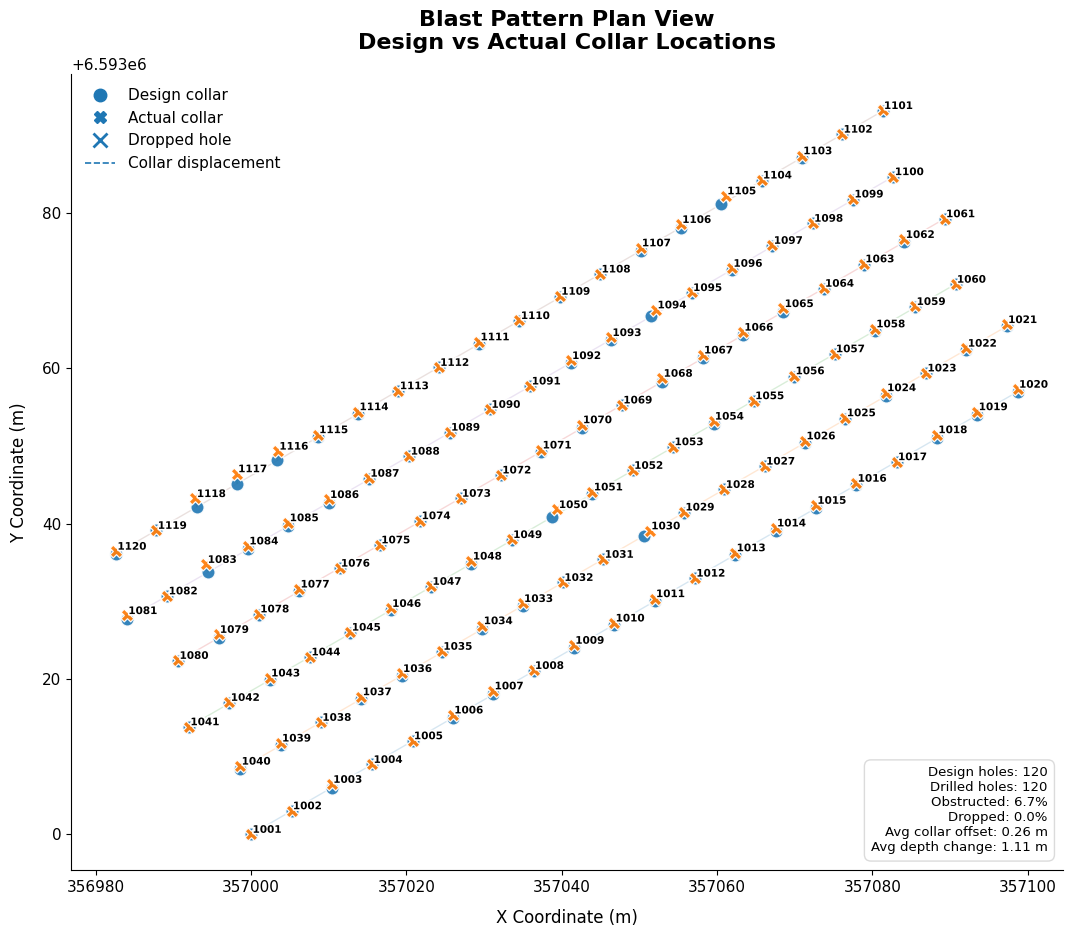

,hole_number,hole_id,row,position_in_row,design_x,design_y,actual_x,actual_y,collar_offset_m,design_hole_length,actual_hole_length,depth_delta_m,obstructed,obstruction_shift_applied_m,dropped,plan_flag,depth_flag,drift_flag
0,1001,PRD1001,1,1,357000.000,6593000.000,357000.000,6593000.000,0.000,11.1,11.100,0.000,False,0.0,False,False,False,False
1,1002,PRD1002,1,2,357005.196,6593003.000,357005.196,6593003.037,0.037,11.1,11.100,0.000,False,0.0,False,False,False,False
2,1003,PRD1003,1,3,357010.392,6593006.000,357010.392,6593006.437,0.437,11.1,11.100,0.000,False,0.0,False,True,False,True
3,1004,PRD1004,1,4,357015.588,6593009.000,357015.588,6593009.000,0.000,11.1,9.884,-1.216,False,0.0,False,False,True,True
4,1005,PRD1005,1,5,357020.785,6593012.000,357020.785,6593012.056,0.056,11.1,11.100,0.000,False,0.0,False,False,False,False
5,1006,PRD1006,1,6,357025.981,6593015.000,357025.981,6593015.373,0.373,11.1,11.100,0.000,False,0.0,False,False,False,False
6,1007,PRD1007,1,7,357031.177,6593018.000,357031.177,6593018.477,0.477,11.1,12.762,1.662,False,0.0,False,True,True,True
7,1008,PRD1008,1,8,357036.373,6593021.000,357036.373,6593021.107,0.107,11.1,13.104,2.004,False,0.0,False,False,True,True
8,1009,PRD1009,1,9,357041.569,6593024.000,357041.569,6593024.355,0.355,11.1,11.305,0.205,False,0.0,False,False,False,False
9,1010,PRD1010,1,10,357046.765,6593027.000,357046.765,6593027.219,0.219,11.1,12.426,1.326,False,0.0,False,False,True,True


Design dataset saved to: blast_design_dataset.csv
Actual dataset saved to: blast_actual_dataset.csv


,pattern_number,hole_number,hole_id,x,y,collar_rl,design_toe_rl,design_bench_height
0,GB-120-001,1001,PRD1001,357000.000,6593000.0,130,118.9,10.0
1,GB-120-001,1002,PRD1002,357005.196,6593003.0,130,118.9,10.0
2,GB-120-001,1003,PRD1003,357010.392,6593006.0,130,118.9,10.0
3,GB-120-001,1004,PRD1004,357015.588,6593009.0,130,118.9,10.0
4,GB-120-001,1005,PRD1005,357020.785,6593012.0,130,118.9,10.0
5,GB-120-001,1006,PRD1006,357025.981,6593015.0,130,118.9,10.0
6,GB-120-001,1007,PRD1007,357031.177,6593018.0,130,118.9,10.0
7,GB-120-001,1008,PRD1008,357036.373,6593021.0,130,118.9,10.0
8,GB-120-001,1009,PRD1009,357041.569,6593024.0,130,118.9,10.0
9,GB-120-001,1010,PRD1010,357046.765,6593027.0,130,118.9,10.0


,pattern_number,hole_number,hole_id,actual_x,actual_y,actual_toe_rl,actual_collar_rl
0,GB-120-001,1001,PRD1001,357000.000,6593000.000,118.900,130
1,GB-120-001,1002,PRD1002,357005.196,6593003.037,118.900,130
2,GB-120-001,1003,PRD1003,357010.392,6593006.437,118.900,130
3,GB-120-001,1004,PRD1004,357015.588,6593009.000,120.116,130
4,GB-120-001,1005,PRD1005,357020.785,6593012.056,118.900,130
5,GB-120-001,1006,PRD1006,357025.981,6593015.373,118.900,130
6,GB-120-001,1007,PRD1007,357031.177,6593018.477,117.238,130
7,GB-120-001,1008,PRD1008,357036.373,6593021.107,116.896,130
8,GB-120-001,1009,PRD1009,357041.569,6593024.355,118.695,130
9,GB-120-001,1010,PRD1010,357046.765,6593027.219,117.574,130


In [4]:
# =============================================================================
# VALIDATION
# =============================================================================

if not (0 <= plan_move_probability <= 1):
	raise ValueError("plan_move_probability must be between 0 and 1.")

if not (0 <= depth_change_probability <= 1):
	raise ValueError("depth_change_probability must be between 0 and 1.")

if not (0 <= obstruction_probability <= 1):
	raise ValueError("obstruction_probability must be between 0 and 1.")

if not (0 <= drop_probability_if_obstructed <= 1):
	raise ValueError("drop_probability_if_obstructed must be between 0 and 1.")

if plan_move_pct_max < 0:
	raise ValueError("plan_move_pct_max must be >= 0.")

if depth_change_pct_max < 0:
	raise ValueError("depth_change_pct_max must be >= 0.")

if obstruction_shift_m < 0:
	raise ValueError("obstruction_shift_m must be >= 0.")

if depth_change_mode not in {"short", "long", "random"}:
	raise ValueError("depth_change_mode must be 'short', 'long', or 'random'.")


# =============================================================================
# FUNCTIONS
# =============================================================================

def generate_design_pattern(
	starting_hole_number: int,
	n_rows: int,
	holes_per_row: int,
	burden: float,
	spacing: float,
	bench_height: float,
	subdrill: float,
	origin_x: float = 0.0,
	origin_y: float = 0.0,
	origin_rl: float = 0.0,
	orientation_deg: float = 0.0,
	numbering_mode: str = "row_major",
	hole_prefix: str = "H",
) -> pd.DataFrame:
	"""
	Generate the design drilling pattern as a staggered pattern.
	Every second row is offset by half the spacing.
	"""

	hole_length = bench_height + subdrill

	theta = np.deg2rad(orientation_deg)
	row_dx = np.cos(theta)
	row_dy = np.sin(theta)

	burden_dx = -np.sin(theta)
	burden_dy = np.cos(theta)

	records = []
	current_hole_number = starting_hole_number

	for row_idx in range(n_rows):
		row_number = row_idx + 1

		# Stagger every second row by half a spacing
		stagger_offset = 0.5 * spacing if row_idx % 2 == 1 else 0.0

		hole_positions = list(range(holes_per_row))
		if numbering_mode.lower() == "snake" and row_idx % 2 == 1:
			hole_positions = hole_positions[::-1]
		elif numbering_mode.lower() not in {"row_major", "snake"}:
			raise ValueError("numbering_mode must be either 'row_major' or 'snake'.")

		for drill_seq_pos, hole_pos_in_row in enumerate(hole_positions):
			along_row_dist = hole_pos_in_row * spacing + stagger_offset
			across_row_dist = row_idx * burden

			x = origin_x + along_row_dist * row_dx + across_row_dist * burden_dx
			y = origin_y + along_row_dist * row_dy + across_row_dist * burden_dy

			records.append({
				"hole_number": current_hole_number,
				"hole_id": f"{hole_prefix}{current_hole_number}",
				"row": row_number,
				"position_in_row": hole_pos_in_row + 1,
				"drill_sequence_in_row": drill_seq_pos + 1,
				"design_x": round(x, 3),
				"design_y": round(y, 3),
				"collar_rl": round(origin_rl, 3),
				"design_bench_height": bench_height,
				"design_subdrill": subdrill,
				"design_hole_length": hole_length,
				"design_toe_rl": round(origin_rl - hole_length, 3),
				"pattern_orientation_deg": orientation_deg,
			})

			current_hole_number += 1

	return pd.DataFrame(records)


def apply_actual_drill_variability(
	df_design: pd.DataFrame,
	spacing: float,
	plan_move_probability: float,
	plan_move_pct_max: float,
	plan_move_direction_deg: float,
	depth_change_probability: float,
	depth_change_pct_max: float,
	depth_change_mode: str,
	origin_x: float,
	origin_y: float,
	obstruction_probability: float,
	obstruction_shift_m: float,
	drop_probability_if_obstructed: float,
	random_seed: int = 13,
) -> pd.DataFrame:
	"""
	Apply drilling variability to design hole collars and hole lengths,
	then apply a secondary obstruction event that may push the hole further
	from origin or cause the hole to be dropped altogether.
	"""

	rng = np.random.default_rng(random_seed)
	df_actual = df_design.copy()

	# Horizontal drift direction unit vector
	move_theta = np.deg2rad(plan_move_direction_deg)
	move_dx = np.cos(move_theta)
	move_dy = np.sin(move_theta)

	actual_x = []
	actual_y = []
	collar_moved = []
	collar_offset_m = []

	actual_hole_length = []
	actual_toe_rl = []
	depth_changed = []
	depth_delta_m = []

	obstructed = []
	obstruction_shift_applied_m = []
	dropped = []

	for _, row in df_actual.iterrows():
		# -------------------------------------------------
		# Horizontal collar movement
		# -------------------------------------------------
		move_triggered = rng.random() < plan_move_probability

		if move_triggered:
			offset_m = rng.uniform(0, plan_move_pct_max * spacing)
			x_actual = row["design_x"] + offset_m * move_dx
			y_actual = row["design_y"] + offset_m * move_dy
		else:
			offset_m = 0.0
			x_actual = row["design_x"]
			y_actual = row["design_y"]

		# -------------------------------------------------
		# Depth variation
		# -------------------------------------------------
		depth_triggered = rng.random() < depth_change_probability
		design_length = row["design_hole_length"]

		if depth_triggered:
			delta_m = rng.uniform(0, depth_change_pct_max * design_length)

			if depth_change_mode == "short":
				actual_length = design_length - delta_m
				signed_delta = -delta_m
			elif depth_change_mode == "long":
				actual_length = design_length + delta_m
				signed_delta = delta_m
			else:  # random
				sign = rng.choice([-1, 1])
				actual_length = design_length + sign * delta_m
				signed_delta = sign * delta_m

			actual_length = max(actual_length, 0.0)
		else:
			actual_length = design_length
			signed_delta = 0.0

		# -------------------------------------------------
		# Secondary obstruction / undrillable adjustment
		# Applied AFTER the normal drilling variability
		# -------------------------------------------------
		obstruction_triggered = rng.random() < obstruction_probability
		shift_applied_m = 0.0
		drop_triggered = False

		if obstruction_triggered:
			# Unit vector from pattern origin to current actual collar
			vec_x = x_actual - origin_x
			vec_y = y_actual - origin_y
			vec_mag = np.hypot(vec_x, vec_y)

			if vec_mag > 0:
				unit_x = vec_x / vec_mag
				unit_y = vec_y / vec_mag
			else:
				# Fallback edge case if collar exactly equals origin
				unit_x = 1.0
				unit_y = 0.0

			# Push collar 1 m further away from origin
			x_actual = x_actual + obstruction_shift_m * unit_x
			y_actual = y_actual + obstruction_shift_m * unit_y
			shift_applied_m = obstruction_shift_m
			offset_m = offset_m + obstruction_shift_m

			# Nested chance that hole is dropped altogether
			drop_triggered = rng.random() < drop_probability_if_obstructed

		toe_rl = row["collar_rl"] - actual_length

		actual_x.append(round(x_actual, 3))
		actual_y.append(round(y_actual, 3))
		collar_moved.append(move_triggered or obstruction_triggered)
		collar_offset_m.append(round(offset_m, 3))

		actual_hole_length.append(round(actual_length, 3))
		actual_toe_rl.append(round(toe_rl, 3))
		depth_changed.append(depth_triggered)
		depth_delta_m.append(round(signed_delta, 3))

		obstructed.append(obstruction_triggered)
		obstruction_shift_applied_m.append(round(shift_applied_m, 3))
		dropped.append(drop_triggered)

	df_actual["actual_x"] = actual_x
	df_actual["actual_y"] = actual_y
	df_actual["collar_moved"] = collar_moved
	df_actual["collar_offset_m"] = collar_offset_m

	df_actual["actual_hole_length"] = actual_hole_length
	df_actual["actual_toe_rl"] = actual_toe_rl
	df_actual["depth_changed"] = depth_changed
	df_actual["depth_delta_m"] = depth_delta_m

	df_actual["obstructed"] = obstructed
	df_actual["obstruction_shift_applied_m"] = obstruction_shift_applied_m
	df_actual["dropped"] = dropped

	return df_actual

def voronoi_finite_polygons_2d(vor, radius=None):
	"""
	Reconstruct infinite Voronoi regions in 2D into finite regions.

	Returns
	-------
	regions : list of lists of ints
		Indices of vertices in each revised Voronoi region.
	vertices : ndarray of float
		Coordinates for revised vertices.
	"""
	if vor.points.shape[1] != 2:
		raise ValueError("Requires 2D input")

	new_regions = []
	new_vertices = vor.vertices.tolist()

	centre = vor.points.mean(axis=0)
	if radius is None:
		radius = vor.points.ptp().max() * 2

	# Map ridge points to ridge vertices
	all_ridges = {}
	for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
		all_ridges.setdefault(p1, []).append((p2, v1, v2))
		all_ridges.setdefault(p2, []).append((p1, v1, v2))

	for p1, region_index in enumerate(vor.point_region):
		vertices = vor.regions[region_index]

		if all(v >= 0 for v in vertices):
			new_regions.append(vertices)
			continue

		ridges = all_ridges[p1]
		new_region = [v for v in vertices if v >= 0]

		for p2, v1, v2 in ridges:
			if v2 < 0:
				v1, v2 = v2, v1
			if v1 >= 0:
				continue

			tangent = vor.points[p2] - vor.points[p1]
			tangent /= np.linalg.norm(tangent)
			normal = np.array([-tangent[1], tangent[0]])

			midpoint = vor.points[[p1, p2]].mean(axis=0)
			direction = np.sign(np.dot(midpoint - centre, normal)) * normal
			far_point = vor.vertices[v2] + direction * radius

			new_vertices.append(far_point.tolist())
			new_region.append(len(new_vertices) - 1)

		vs = np.asarray([new_vertices[v] for v in new_region])
		centroid = vs.mean(axis=0)
		angles = np.arctan2(vs[:, 1] - centroid[1], vs[:, 0] - centroid[0])
		new_region = [v for _, v in sorted(zip(angles, new_region))]

		new_regions.append(new_region)

	return new_regions, np.asarray(new_vertices)


def build_pattern_boundary_polygon(
	points: np.ndarray,
	spacing: float,
	burden: float,
	orientation_deg: float,
) -> Polygon:
	"""
	Build an outer polygon around the drilled pattern by taking the convex hull
	of the actual drilled collars and buffering it anisotropically in the row
	and burden directions.

	This gives a more realistic pattern footprint than a simple rectangular box.
	"""
	if len(points) < 3:
		raise ValueError("At least 3 points are required to build a pattern boundary polygon.")

	theta = np.deg2rad(orientation_deg)

	# Local pattern axes
	row_vec = np.array([np.cos(theta), np.sin(theta)])
	burden_vec = np.array([-np.sin(theta), np.cos(theta)])

	centre = points.mean(axis=0)
	rel = points - centre

	# Transform into local row/burden coordinates
	local_x = rel @ row_vec
	local_y = rel @ burden_vec

	# Build convex hull in local coordinates
	local_points = np.column_stack([local_x, local_y])
	local_hull = MultiPoint(local_points).convex_hull

	# Buffer the hull by about half spacing / half burden so the footprint
	# represents the pattern envelope rather than just the collar centres
	buffered_local_hull = local_hull.buffer(
		0.0
	)

	minx, miny, maxx, maxy = buffered_local_hull.bounds
	minx -= spacing * 0.5
	maxx += spacing * 0.5
	miny -= burden * 0.5
	maxy += burden * 0.5

	local_rect = Polygon([
		(minx, miny),
		(maxx, miny),
		(maxx, maxy),
		(minx, maxy),
	])

	# Intersect with hull buffered a little more softly to keep a natural end shape
	softened_hull = local_hull.buffer(min(spacing, burden) * 0.35)
	final_local = local_rect.intersection(softened_hull.buffer(0))

	# Transform back to global coordinates
	coords_global = []
	for x_l, y_l in np.asarray(final_local.exterior.coords):
		xy = centre + x_l * row_vec + y_l * burden_vec
		coords_global.append(tuple(xy))

	return Polygon(coords_global)

# =============================================================================
# GENERATE DATA
# =============================================================================

df_design = generate_design_pattern(
	starting_hole_number=starting_hole_number,
	n_rows=n_rows,
	holes_per_row=holes_per_row,
	burden=burden,
	spacing=spacing,
	bench_height=bench_height,
	subdrill=subdrill,
	origin_x=origin_x,
	origin_y=origin_y,
	origin_rl=origin_rl,
	orientation_deg=pattern_orientation_deg,
	numbering_mode=numbering_mode,
	hole_prefix=hole_prefix,
)

df_actual = apply_actual_drill_variability(
	df_design=df_design,
	spacing=spacing,
	plan_move_probability=plan_move_probability,
	plan_move_pct_max=plan_move_pct_max,
	plan_move_direction_deg=plan_move_direction_deg,
	depth_change_probability=depth_change_probability,
	depth_change_pct_max=depth_change_pct_max,
	depth_change_mode=depth_change_mode,
	origin_x=origin_x,
	origin_y=origin_y,
	obstruction_probability=obstruction_probability,
	obstruction_shift_m=obstruction_shift_m,
	drop_probability_if_obstructed=drop_probability_if_obstructed,
	random_seed=random_seed,
)

display(df_actual.head(20))

print(f"Total design holes: {len(df_actual)}")
print(f"Collars moved: {df_actual['collar_moved'].sum()} / {len(df_actual)}")
print(f"Depth changed: {df_actual['depth_changed'].sum()} / {len(df_actual)}")
print(f"Obstructed holes: {df_actual['obstructed'].sum()} / {len(df_actual)}")
print(f"Dropped holes: {df_actual['dropped'].sum()} / {len(df_actual)}")

# Drilled holes only for plotting actual execution
df_drilled = df_actual[~df_actual["dropped"]].copy()


# =============================================================================
# FLAG HOLES WITH MATERIAL DRIFT
# =============================================================================

plan_flag_threshold_m = origin_flag * spacing
depth_flag_threshold_m = depth_flag * design_hole_length

df_actual["plan_flag"] = df_actual["collar_offset_m"].abs() >= plan_flag_threshold_m
df_actual["depth_flag"] = df_actual["depth_delta_m"].abs() >= depth_flag_threshold_m
df_actual["drift_flag"] = df_actual["plan_flag"] | df_actual["depth_flag"]

df_drilled["plan_flag"] = df_drilled["collar_offset_m"].abs() >= plan_flag_threshold_m
df_drilled["depth_flag"] = df_drilled["depth_delta_m"].abs() >= depth_flag_threshold_m
df_drilled["drift_flag"] = df_drilled["plan_flag"] | df_drilled["depth_flag"]

print(f"Flag threshold - plan drift: {plan_flag_threshold_m:.3f} m")
print(f"Flag threshold - depth drift: {depth_flag_threshold_m:.3f} m")
print(f"Flagged drilled holes: {df_drilled['drift_flag'].sum()} / {len(df_drilled)}")


# =============================================================================
# 2D PLAN VIEW - DESIGN VS ACTUAL
# =============================================================================

plt.rcParams.update({
	"font.size": 11,
	"axes.titlesize": 16,
	"axes.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(12.5, 9.5), facecolor="white")
ax.set_facecolor("white")

# Subtle row guide lines from design
for row_num in sorted(df_actual["row"].unique()):
	df_row = df_actual[df_actual["row"] == row_num].sort_values("position_in_row")
	ax.plot(
		df_row["design_x"],
		df_row["design_y"],
		linestyle="-",
		linewidth=1.0,
		alpha=0.18,
		zorder=1,
	)

# Connection lines between design and drilled actual
for _, row in df_drilled.iterrows():
	ax.plot(
		[row["design_x"], row["actual_x"]],
		[row["design_y"], row["actual_y"]],
		linestyle="--",
		linewidth=1.0,
		alpha=0.45,
		zorder=2,
	)

# Design collars
ax.scatter(
	df_actual["design_x"],
	df_actual["design_y"],
	s=95,
	alpha=0.9,
	edgecolors="white",
	linewidths=1.2,
	zorder=3,
	label="Design collar",
)

# Drilled actual collars
ax.scatter(
	df_drilled["actual_x"],
	df_drilled["actual_y"],
	s=85,
	marker="X",
	alpha=0.95,
	edgecolors="white",
	linewidths=0.9,
	zorder=4,
	label="Actual collar",
)

# Dropped holes shown at design position
df_dropped = df_actual[df_actual["dropped"]]
if not df_dropped.empty:
	ax.scatter(
		df_dropped["design_x"],
		df_dropped["design_y"],
		s=140,
		marker="x",
		linewidths=2.0,
		alpha=0.95,
		zorder=5,
		label="Dropped hole",
	)

# Labels for drilled holes
for _, row in df_drilled.iterrows():
	txt = ax.text(
		row["actual_x"] + 0.18,
		row["actual_y"] + 0.18,
		str(row["hole_number"]),
		fontsize=7.5,
		weight="bold",
		zorder=6,
	)
	txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])

# Labels for dropped holes
for _, row in df_dropped.iterrows():
	txt = ax.text(
		row["design_x"] + 0.18,
		row["design_y"] + 0.18,
		f"{row['hole_number']} (d)",
		fontsize=7.0,
		weight="bold",
		zorder=6,
	)
	txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])

ax.set_title("Blast Pattern Plan View\nDesign vs Actual Collar Locations", pad=18, weight="bold")
ax.set_xlabel("X Coordinate (m)", labelpad=10)
ax.set_ylabel("Y Coordinate (m)", labelpad=10)
ax.set_aspect("equal")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

x_all = np.r_[df_actual["design_x"].values, df_drilled["actual_x"].values if len(df_drilled) else df_actual["design_x"].values]
y_all = np.r_[df_actual["design_y"].values, df_drilled["actual_y"].values if len(df_drilled) else df_actual["design_y"].values]
x_pad = max((x_all.max() - x_all.min()) * 0.05, 2.0)
y_pad = max((y_all.max() - y_all.min()) * 0.05, 2.0)
ax.set_xlim(x_all.min() - x_pad, x_all.max() + x_pad)
ax.set_ylim(y_all.min() - y_pad, y_all.max() + y_pad)

legend_elements = [
	Line2D([0], [0], marker="o", linestyle="", markersize=9, label="Design collar"),
	Line2D([0], [0], marker="X", linestyle="", markersize=9, label="Actual collar"),
	Line2D([0], [0], marker="x", linestyle="", markersize=10, markeredgewidth=2, label="Dropped hole"),
	Line2D([0], [0], linestyle="--", linewidth=1.2, label="Collar displacement"),
]
ax.legend(
	handles=legend_elements,
	loc="upper left",
	frameon=False,
)

moved_pct = 100 * df_actual["collar_moved"].mean()
depth_pct = 100 * df_actual["depth_changed"].mean()
obstructed_pct = 100 * df_actual["obstructed"].mean()
dropped_pct = 100 * df_actual["dropped"].mean()
avg_offset = df_actual["collar_offset_m"].mean()
avg_depth_delta = df_actual["depth_delta_m"].abs().mean()

summary_text = (
	f"Design holes: {len(df_actual)}\n"
	f"Drilled holes: {len(df_drilled)}\n"
	f"Obstructed: {obstructed_pct:.1f}%\n"
	f"Dropped: {dropped_pct:.1f}%\n"
	f"Avg collar offset: {avg_offset:.2f} m\n"
	f"Avg depth change: {avg_depth_delta:.2f} m"
)

ax.text(
	0.985, 0.02,
	summary_text,
	transform=ax.transAxes,
	ha="right", va="bottom",
	fontsize=9.5,
	bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="0.85", alpha=0.95),
)

plt.tight_layout()
plt.show()


# =============================================================================
# 2D PLAN VIEW - VORONOI CELLS AROUND ACTUAL DRILLED HOLES
# =============================================================================

# =============================================================================
# INTERACTIVE VORONOI (PLOTLY)
# =============================================================================

if len(df_drilled) < 3:
    print("Need at least 3 drilled holes.")
else:
    points = df_drilled[["actual_x", "actual_y"]].to_numpy()
    vor = Voronoi(points)
    regions, vertices = voronoi_finite_polygons_2d(vor)

    pattern_polygon = build_pattern_boundary_polygon(
        points=points,
        spacing=spacing,
        burden=burden,
        orientation_deg=pattern_orientation_deg,
    )

    fig = go.Figure()

    # Track whether a legend item has already been shown
    legend_seen = {
        "Normal influence cells": False,
        "Flagged influence cells": False,
    }

    # ---------------------------------------------------------------------
    # VORONOI CELLS
    # ---------------------------------------------------------------------
    for i, region in enumerate(regions):
        polygon_coords = vertices[region]
        poly = Polygon(polygon_coords)

        if not poly.is_valid:
            poly = poly.buffer(0)

        clipped = poly.intersection(pattern_polygon)
        if clipped.is_empty:
            continue

        hole = df_drilled.iloc[i]
        is_flagged = bool(hole["drift_flag"])

        fill_colour = "rgba(220,235,220,0.65)" if not is_flagged else "rgba(246,217,212,0.75)"
        edge_colour = "rgba(47,143,58,0.95)" if not is_flagged else "rgba(214,69,47,0.95)"
        trace_name = "Normal influence cells" if not is_flagged else "Flagged influence cells"

        geometries = [clipped] if clipped.geom_type == "Polygon" else list(clipped.geoms)

        for geom in geometries:
            x_poly, y_poly = geom.exterior.xy

            # Convert shapely array.array outputs to standard Python lists for Plotly
            x_poly = list(x_poly)
            y_poly = list(y_poly)

            fig.add_trace(go.Scatter(
                x=x_poly,
                y=y_poly,
                mode="lines",
                fill="toself",
                fillcolor=fill_colour,
                line=dict(color=edge_colour, width=1.1),
                name=trace_name,
                legendgroup=trace_name,
                showlegend=not legend_seen[trace_name],
                hoverinfo="skip",
            ))

            legend_seen[trace_name] = True

    # ---------------------------------------------------------------------
    # PATTERN BOUNDARY
    # ---------------------------------------------------------------------
    px, py = pattern_polygon.exterior.xy
    px = list(px)
    py = list(py)

    fig.add_trace(go.Scatter(
        x=px,
        y=py,
        mode="lines",
        line=dict(color="#1f6fb2", width=3),
        name="Pattern boundary",
        hoverinfo="skip",
    ))

    # ---------------------------------------------------------------------
    # COLLARS
    # ---------------------------------------------------------------------
    df_normal = df_drilled[~df_drilled["drift_flag"]]
    df_flagged = df_drilled[df_drilled["drift_flag"]]

    fig.add_trace(go.Scatter(
        x=df_normal["actual_x"].to_list(),
        y=df_normal["actual_y"].to_list(),
        mode="markers",
        marker=dict(
            size=8,
            color="#2b6ea6",
            line=dict(width=1.2, color="white"),
        ),
        name="Actual collars",
        legendgroup="Actual collars",
        text=df_normal["hole_number"].astype(str).to_list(),
        customdata=np.stack([
            df_normal["collar_offset_m"].to_numpy(),
            df_normal["depth_delta_m"].to_numpy(),
        ], axis=1) if len(df_normal) else None,
        hovertemplate=(
            "<b>Hole %{text}</b><br>"
            "X: %{x:.2f}<br>"
            "Y: %{y:.2f}<br>"
            "Collar offset: %{customdata[0]:.2f} m<br>"
            "Depth delta: %{customdata[1]:.2f} m"
            "<extra></extra>"
        ),
    ))

    fig.add_trace(go.Scatter(
        x=df_flagged["actual_x"].to_list(),
        y=df_flagged["actual_y"].to_list(),
        mode="markers",
        marker=dict(
            size=9,
            color="#f28e1c",
            line=dict(width=1.2, color="white"),
        ),
        name="Flagged collars",
        legendgroup="Flagged collars",
        text=df_flagged["hole_number"].astype(str).to_list(),
        customdata=np.stack([
            df_flagged["collar_offset_m"].to_numpy(),
            df_flagged["depth_delta_m"].to_numpy(),
        ], axis=1) if len(df_flagged) else None,
        hovertemplate=(
            "<b>Hole %{text}</b><br>"
            "X: %{x:.2f}<br>"
            "Y: %{y:.2f}<br>"
            "Collar offset: %{customdata[0]:.2f} m<br>"
            "Depth delta: %{customdata[1]:.2f} m"
            "<extra></extra>"
        ),
    ))

    # ---------------------------------------------------------------------
    # LABELS
    # ---------------------------------------------------------------------
    fig.add_trace(go.Scatter(
        x=df_drilled["actual_x"].to_list(),
        y=df_drilled["actual_y"].to_list(),
        mode="text",
        text=df_drilled["hole_number"].astype(str).to_list(),
        textposition="top center",
        textfont=dict(size=9, color="#1d1d1f"),
        name="Hole labels",
        legendgroup="Hole labels",
        hoverinfo="skip",
    ))

    # ---------------------------------------------------------------------
    # SUMMARY ANNOTATION
    # ---------------------------------------------------------------------
    n_drilled = len(df_drilled)
    n_flagged = int(df_drilled["drift_flag"].sum())
    n_dropped = int(df_actual["dropped"].sum())
    flagged_pct = 100 * n_flagged / n_drilled if n_drilled else 0.0
    avg_offset = df_drilled["collar_offset_m"].mean() if n_drilled else 0.0
    avg_depth_delta = df_drilled["depth_delta_m"].abs().mean() if n_drilled else 0.0

    summary_text = (
        f"Drilled holes used: {n_drilled}<br>"
        f"Flagged holes: {n_flagged} ({flagged_pct:.1f}%)<br>"
        f"Dropped holes excluded: {n_dropped}<br>"
        f"Mean collar offset: {avg_offset:.2f} m<br>"
        f"Mean depth change: {avg_depth_delta:.2f} m"
    )

    # ---------------------------------------------------------------------
    # LAYOUT
    # ---------------------------------------------------------------------
    fig.update_layout(
        title=dict(
            text="Actual Drilled Hole Voronoi Plan View",
            x=0.5,
            xanchor="center",
        ),
        xaxis=dict(
            title="X Coordinate (m)",
            showgrid=False,
            zeroline=False,
            tickformat=".0f",   # full numbers, no commas
        ),
        yaxis=dict(
            title="Y Coordinate (m)",
            showgrid=False,
            zeroline=False,
            scaleanchor="x",
            scaleratio=1,
            tickformat=".0f",   # full numbers, no commas
        ),
        legend=dict(
            bgcolor="rgba(255,255,255,0.92)",
            bordercolor="rgba(0,0,0,0.10)",
            borderwidth=1,
            x=0.01,
            y=0.99,
        ),
        plot_bgcolor="white",
        paper_bgcolor="white",
        height=850,
        margin=dict(l=30, r=30, t=70, b=30),
        annotations=[
            dict(
                x=0.995,
                y=0.02,
                xref="paper",
                yref="paper",
                xanchor="right",
                yanchor="bottom",
                align="left",
                text=summary_text,
                showarrow=False,
                bgcolor="rgba(255,255,255,0.96)",
                bordercolor="rgba(0,0,0,0.12)",
                borderwidth=1,
                borderpad=8,
                font=dict(size=11, color="#233142"),
            )
        ],
    )

    fig.show()

# =============================================================================
# 3D VIEW - ACTUAL HOLES WITH DRIFT FLAGS
# =============================================================================

fig_3d = go.Figure()

normal_colour = "green"
flag_colour = "red"

for _, row in df_drilled.iterrows():
	hole_colour = flag_colour if row["drift_flag"] else normal_colour

	hover_text = (
		f"<b>{row['hole_id']}</b><br>"
		f"Hole number: {row['hole_number']}<br>"
		f"Row: {row['row']}<br>"
		f"Position in row: {row['position_in_row']}<br>"
		f"Actual X: {row['actual_x']:.2f}<br>"
		f"Actual Y: {row['actual_y']:.2f}<br>"
		f"Collar RL: {row['collar_rl']:.2f}<br>"
		f"Actual Toe RL: {row['actual_toe_rl']:.2f}<br>"
		f"Actual Length: {row['actual_hole_length']:.2f} m<br>"
		f"Collar Offset: {row['collar_offset_m']:.2f} m<br>"
		f"Depth Delta: {row['depth_delta_m']:.2f} m<br>"
		f"Obstructed: {row['obstructed']}<br>"
		f"Shift Applied: {row['obstruction_shift_applied_m']:.2f} m<br>"
		f"Plan Flag: {row['plan_flag']}<br>"
		f"Depth Flag: {row['depth_flag']}<br>"
		f"<b>Flagged: {row['drift_flag']}</b>"
	)

	fig_3d.add_trace(go.Scatter3d(
		x=[row["actual_x"], row["actual_x"]],
		y=[row["actual_y"], row["actual_y"]],
		z=[row["collar_rl"], row["actual_toe_rl"]],
		mode="lines",
		line=dict(color=hole_colour, width=6),
		hoverinfo="text",
		text=[hover_text, hover_text],
		showlegend=False,
	))

df_normal = df_drilled[~df_drilled["drift_flag"]]
df_flagged = df_drilled[df_drilled["drift_flag"]]

fig_3d.add_trace(go.Scatter3d(
	x=df_normal["actual_x"],
	y=df_normal["actual_y"],
	z=df_normal["collar_rl"],
	mode="markers+text",
	marker=dict(size=5, color=normal_colour, symbol="circle"),
	text=df_normal["hole_number"].astype(str),
	textposition="top center",
	name="Normal holes",
	hovertemplate=(
		"<b>%{text}</b><br>"
		"X: %{x:.2f}<br>"
		"Y: %{y:.2f}<br>"
		"RL: %{z:.2f}<extra></extra>"
	),
))

fig_3d.add_trace(go.Scatter3d(
	x=df_flagged["actual_x"],
	y=df_flagged["actual_y"],
	z=df_flagged["collar_rl"],
	mode="markers+text",
	marker=dict(size=6, color=flag_colour, symbol="circle"),
	text=df_flagged["hole_number"].astype(str),
	textposition="top center",
	name="Flagged holes",
	hovertemplate=(
		"<b>%{text}</b><br>"
		"X: %{x:.2f}<br>"
		"Y: %{y:.2f}<br>"
		"RL: %{z:.2f}<extra></extra>"
	),
))

fig_3d.add_trace(go.Scatter3d(
	x=df_normal["actual_x"],
	y=df_normal["actual_y"],
	z=df_normal["actual_toe_rl"],
	mode="markers",
	marker=dict(size=3.5, color=normal_colour, symbol="diamond"),
	name="Normal toes",
	hovertemplate=(
		"Toe<br>"
		"X: %{x:.2f}<br>"
		"Y: %{y:.2f}<br>"
		"RL: %{z:.2f}<extra></extra>"
	),
))

fig_3d.add_trace(go.Scatter3d(
	x=df_flagged["actual_x"],
	y=df_flagged["actual_y"],
	z=df_flagged["actual_toe_rl"],
	mode="markers",
	marker=dict(size=4.5, color=flag_colour, symbol="diamond"),
	name="Flagged toes",
	hovertemplate=(
		"Toe<br>"
		"X: %{x:.2f}<br>"
		"Y: %{y:.2f}<br>"
		"RL: %{z:.2f}<extra></extra>"
	),
))

fig_3d.update_layout(
	title={
		"text": "Actual Drilled Hole Pattern - Interactive 3D View",
		"x": 0.5,
		"xanchor": "center",
	},
	height=800,
	margin=dict(l=10, r=10, t=60, b=10),
	scene=dict(
		xaxis_title="X Coordinate (m)",
		yaxis_title="Y Coordinate (m)",
		zaxis_title="RL (m)",
		xaxis=dict(showbackground=False, gridcolor="rgba(0,0,0,0.08)"),
		yaxis=dict(showbackground=False, gridcolor="rgba(0,0,0,0.08)"),
		zaxis=dict(showbackground=False, gridcolor="rgba(0,0,0,0.08)"),
		aspectmode="data",
		camera=dict(eye=dict(x=1.6, y=1.6, z=1.1)),
	),
	legend=dict(
		orientation="h",
		yanchor="bottom",
		y=1.02,
		xanchor="right",
		x=1.0
	),
)

fig_3d.show()

# =============================================================================
# PATTERN NUMBER GENERATION
# =============================================================================

# Calculate design bottom RL (top RL - bench height)
df_design["design_bottom_rl"] = (
	df_design["collar_rl"] - df_design["design_bench_height"]
).round(0).astype(int)

# Create sequence per pattern (assumes one pattern per dataset for now)
pattern_sequence = 1  # can expand later if multiple patterns

# Format sequence with leading zeros
pattern_seq_str = f"{pattern_sequence:03d}"

# Create pattern number
df_design["pattern_number"] = (
	pit_name
	+ "-"
	+ df_design["design_bottom_rl"].astype(str)
	+ "-"
	+ pattern_seq_str
)

df_actual["pattern_number"] = df_design["pattern_number"]


# =============================================================================
# SUMMARY TABLE
# =============================================================================

summary_cols = [
	"hole_number",
	"hole_id",
	"row",
	"position_in_row",
	"design_x",
	"design_y",
	"actual_x",
	"actual_y",
	"collar_offset_m",
	"design_hole_length",
	"actual_hole_length",
	"depth_delta_m",
	"obstructed",
	"obstruction_shift_applied_m",
	"dropped",
	"plan_flag",
	"depth_flag",
	"drift_flag",
]

display(df_actual[summary_cols].head(30))

# =============================================================================
# EXPORT CLEAN DESIGN AND ACTUAL DATASETS
# =============================================================================

# Design export
df_design_export = df_design[[
	"pattern_number",
	"hole_number",
	"hole_id",
	"design_x",
	"design_y",
	"collar_rl",
	"design_toe_rl",
	"design_bench_height",
]].copy()

df_design_export = df_design_export.rename(columns={
	"design_x": "x",
	"design_y": "y",
	"collar_rl": "collar_rl",
	"design_toe_rl": "design_toe_rl",
	"design_bench_height": "design_bench_height",
})

# Actual export
df_actual_export = df_actual[[
	"pattern_number",
	"hole_number",
	"hole_id",
	"actual_x",
	"actual_y",
	"actual_toe_rl",
	"collar_rl",
]].copy()

df_actual_export = df_actual_export.rename(columns={
	"actual_x": "actual_x",
	"actual_y": "actual_y",
	"actual_toe_rl": "actual_toe_rl",
	"collar_rl": "actual_collar_rl",
})

# Output file names
design_output_file = "blast_design_dataset.csv"
actual_output_file = "blast_actual_dataset.csv"

# Save to CSV
df_design_export.to_csv(design_output_file, index=False)
df_actual_export.to_csv(actual_output_file, index=False)

print(f"Design dataset saved to: {design_output_file}")
print(f"Actual dataset saved to: {actual_output_file}")

display(df_design_export.head(10))
display(df_actual_export.head(10))

---

# <span style="color:snow; font-weight:bold">💥 3. Explosive Loading Dataset Generator (Design & Actual)

This cell extends df_design and df_actual with explosive loading information then exports enriched design and actual datasets.

In [5]:
# =============================================================================
# VALIDATION
# =============================================================================

if explosive_density_gcc <= 0:
	raise ValueError("explosive_density_gcc must be > 0.")

if hole_diameter_mm <= 0:
	raise ValueError("hole_diameter_mm must be > 0.")

if design_stemming_m < 0:
	raise ValueError("design_stemming_m must be >= 0.")

if not (0 <= actual_explosive_variation_probability <= 1):
	raise ValueError("actual_explosive_variation_probability must be between 0 and 1.")

if actual_explosive_variation_pct_max < 0:
	raise ValueError("actual_explosive_variation_pct_max must be >= 0.")

if actual_explosive_variation_mode not in {"under", "over", "random"}:
	raise ValueError("actual_explosive_variation_mode must be 'under', 'over', or 'random'.")


# =============================================================================
# HELPERS
# =============================================================================

def explosive_density_gcc_to_kgm3(density_gcc: float) -> float:
	"""
	Convert density from g/cc to kg/m3.
	1 g/cc = 1000 kg/m3
	"""
	return density_gcc * 1000.0


def hole_cross_section_area_m2(hole_diameter_mm: float) -> float:
	"""
	Compute blast hole cross-sectional area in m2.
	"""
	diameter_m = hole_diameter_mm / 1000.0
	radius_m = diameter_m / 2.0
	return np.pi * radius_m**2


def calculate_explosive_kg(column_length_m: float, area_m2: float, density_kgm3: float) -> float:
	"""
	Calculate explosive mass from charged column length.
	"""
	column_length_m = max(column_length_m, 0.0)
	volume_m3 = column_length_m * area_m2
	return volume_m3 * density_kgm3


def calculate_column_length_from_kg(explosive_kg: float, area_m2: float, density_kgm3: float) -> float:
	"""
	Back-calculate charged column length from explosive mass.
	"""
	if area_m2 <= 0 or density_kgm3 <= 0:
		raise ValueError("Area and density must both be > 0.")
	return max(explosive_kg, 0.0) / (area_m2 * density_kgm3)


def add_design_loading(
	df_design: pd.DataFrame,
	explosive_product: str,
	explosive_density_gcc: float,
	hole_diameter_mm: float,
	design_stemming_m: float,
) -> pd.DataFrame:
	"""
	Add design explosive loading fields to the design dataset.
	"""
	df = df_design.copy()

	density_kgm3 = explosive_density_gcc_to_kgm3(explosive_density_gcc)
	area_m2 = hole_cross_section_area_m2(hole_diameter_mm)

	df["explosive_product"] = explosive_product
	df["explosive_density_gcc"] = explosive_density_gcc
	df["hole_diameter_mm"] = hole_diameter_mm
	df["design_stemming_m"] = design_stemming_m

	df["design_explosive_column_m"] = (
		df["design_hole_length"] - df["design_stemming_m"]
	).clip(lower=0.0)

	df["design_explosive_kg"] = df["design_explosive_column_m"].apply(
		lambda x: calculate_explosive_kg(x, area_m2, density_kgm3)
	)

	df["design_powder_factor_proxy_kg_per_m"] = (
		df["design_explosive_kg"] / df["design_hole_length"].replace(0, np.nan)
	)

	# rounding
	round_cols = [
		"design_stemming_m",
		"design_explosive_column_m",
		"design_explosive_kg",
		"design_powder_factor_proxy_kg_per_m",
	]
	df[round_cols] = df[round_cols].round(3)

	return df


def add_actual_loading(
	df_actual: pd.DataFrame,
	explosive_product: str,
	explosive_density_gcc: float,
	hole_diameter_mm: float,
	design_stemming_m: float,
	actual_explosive_variation_probability: float,
	actual_explosive_variation_pct_max: float,
	actual_explosive_variation_mode: str,
	random_seed: int = 13,
) -> pd.DataFrame:
	"""
	Add actual explosive loading fields to the actual dataset.
	Randomness is applied to actual explosive kg, then actual stemming is
	back-calculated from the resulting explosive column.
	Dropped holes are assigned zero explosive.
	"""
	rng = np.random.default_rng(random_seed)
	df = df_actual.copy()

	density_kgm3 = explosive_density_gcc_to_kgm3(explosive_density_gcc)
	area_m2 = hole_cross_section_area_m2(hole_diameter_mm)

	df["explosive_product"] = explosive_product
	df["explosive_density_gcc"] = explosive_density_gcc
	df["hole_diameter_mm"] = hole_diameter_mm
	df["design_stemming_m"] = design_stemming_m

	# First calculate the design-based charge for the ACTUAL drilled hole length
	df["design_equivalent_explosive_column_m_actual_hole"] = (
		df["actual_hole_length"] - design_stemming_m
	).clip(lower=0.0)

	df["design_equivalent_explosive_kg_actual_hole"] = df[
		"design_equivalent_explosive_column_m_actual_hole"
	].apply(lambda x: calculate_explosive_kg(x, area_m2, density_kgm3))

	actual_explosive_kg = []
	actual_explosive_delta_kg = []
	explosive_load_changed = []
	actual_explosive_column_m = []
	actual_stemming_m = []

	for _, row in df.iterrows():
		# Dropped holes: no explosive loaded
		if bool(row.get("dropped", False)):
			actual_kg = 0.0
			actual_col_m = 0.0
			stem_m = row["actual_hole_length"]
			delta_kg = -row["design_equivalent_explosive_kg_actual_hole"]
			changed = False

		else:
			design_kg = row["design_equivalent_explosive_kg_actual_hole"]
			actual_length = row["actual_hole_length"]

			variation_triggered = rng.random() < actual_explosive_variation_probability

			if variation_triggered:
				delta_pct = rng.uniform(0, actual_explosive_variation_pct_max)

				if actual_explosive_variation_mode == "under":
					signed_pct = -delta_pct
				elif actual_explosive_variation_mode == "over":
					signed_pct = delta_pct
				else:
					signed_pct = rng.choice([-1, 1]) * delta_pct

				proposed_kg = design_kg * (1 + signed_pct)
			else:
				proposed_kg = design_kg
				signed_pct = 0.0

			# Cap explosive column to hole length so stemming cannot go negative
			max_possible_kg = calculate_explosive_kg(actual_length, area_m2, density_kgm3)
			actual_kg = min(max(proposed_kg, 0.0), max_possible_kg)

			actual_col_m = calculate_column_length_from_kg(actual_kg, area_m2, density_kgm3)
			stem_m = max(actual_length - actual_col_m, 0.0)
			delta_kg = actual_kg - design_kg
			changed = variation_triggered

		actual_explosive_kg.append(round(actual_kg, 3))
		actual_explosive_delta_kg.append(round(delta_kg, 3))
		explosive_load_changed.append(changed)
		actual_explosive_column_m.append(round(actual_col_m, 3))
		actual_stemming_m.append(round(stem_m, 3))

	df["actual_explosive_kg"] = actual_explosive_kg
	df["actual_explosive_delta_kg"] = actual_explosive_delta_kg
	df["explosive_load_changed"] = explosive_load_changed
	df["actual_explosive_column_m"] = actual_explosive_column_m
	df["actual_stemming_m"] = actual_stemming_m

	df["actual_powder_factor_proxy_kg_per_m"] = (
		df["actual_explosive_kg"] / df["actual_hole_length"].replace(0, np.nan)
	).round(3)

	df["design_equivalent_explosive_kg_actual_hole"] = df[
		"design_equivalent_explosive_kg_actual_hole"
	].round(3)

	return df


# =============================================================================
# APPLY LOADING TO DESIGN AND ACTUAL DATASETS
# =============================================================================

df_design_loaded = add_design_loading(
	df_design=df_design,
	explosive_product=explosive_product,
	explosive_density_gcc=explosive_density_gcc,
	hole_diameter_mm=hole_diameter_mm,
	design_stemming_m=design_stemming_m,
)

df_actual_loaded = add_actual_loading(
	df_actual=df_actual,
	explosive_product=explosive_product,
	explosive_density_gcc=explosive_density_gcc,
	hole_diameter_mm=hole_diameter_mm,
	design_stemming_m=design_stemming_m,
	actual_explosive_variation_probability=actual_explosive_variation_probability,
	actual_explosive_variation_pct_max=actual_explosive_variation_pct_max,
	actual_explosive_variation_mode=actual_explosive_variation_mode,
	random_seed=random_seed + 100,  # separate stream from drilling variability
)


# =============================================================================
# EXPORT TABLES
# =============================================================================

df_design_export_loaded = df_design_loaded[[
	"pattern_number",
	"hole_number",
	"hole_id",
	"design_x",
	"design_y",
	"collar_rl",
	"design_toe_rl",
	"design_bench_height",
	"design_hole_length",
	"explosive_product",
	"explosive_density_gcc",
	"hole_diameter_mm",
	"design_stemming_m",
	"design_explosive_column_m",
	"design_explosive_kg",
]].copy()

df_design_export_loaded = df_design_export_loaded.rename(columns={
	"design_x": "x",
	"design_y": "y",
})

df_actual_export_loaded = df_actual_loaded[[
	"pattern_number",
	"hole_number",
	"hole_id",
	"actual_x",
	"actual_y",
	"actual_toe_rl",
	"collar_rl",
	"actual_hole_length",
	"dropped",
	"explosive_product",
	"explosive_density_gcc",
	"hole_diameter_mm",
	"design_stemming_m",
	"design_equivalent_explosive_kg_actual_hole",
	"actual_stemming_m",
	"actual_explosive_column_m",
	"actual_explosive_kg",
	"actual_explosive_delta_kg",
	"explosive_load_changed",
]].copy()

df_actual_export_loaded = df_actual_export_loaded.rename(columns={
	"collar_rl": "actual_collar_rl",
})


# =============================================================================
# SAVE TO CSV
# =============================================================================

df_design_export_loaded.to_csv(design_output_file_loaded, index=False)
df_actual_export_loaded.to_csv(actual_output_file_loaded, index=False)


# =============================================================================
# SUMMARY
# =============================================================================

print("Explosives loading complete.")
print(f"Design loaded dataset saved to: {design_output_file_loaded}")
print(f"Actual loaded dataset saved to: {actual_output_file_loaded}")
print()

print("Design summary")
print(f"  Product: {explosive_product}")
print(f"  Density: {explosive_density_gcc:.2f} g/cc")
print(f"  Hole diameter: {hole_diameter_mm:.1f} mm")
print(f"  Design stemming: {design_stemming_m:.2f} m")
print(f"  Total design explosive: {df_design_loaded['design_explosive_kg'].sum():,.1f} kg")
print()

print("Actual summary")
print(f"  Total actual explosive: {df_actual_loaded['actual_explosive_kg'].sum():,.1f} kg")
print(f"  Avg actual stemming: {df_actual_loaded.loc[~df_actual_loaded['dropped'], 'actual_stemming_m'].mean():.2f} m")
print(f"  Explosive loads changed: {df_actual_loaded['explosive_load_changed'].sum()} / {len(df_actual_loaded)}")
print(f"  Dropped holes: {df_actual_loaded['dropped'].sum()} / {len(df_actual_loaded)}")
print()

display(df_design_export_loaded.head(10))
display(df_actual_export_loaded.head(10))

Explosives loading complete.
Design loaded dataset saved to: charge_design.csv
Actual loaded dataset saved to: charge_actuals.csv

Design summary
  Product: ANFO
  Density: 0.80 g/cc
  Hole diameter: 165.0 mm
  Design stemming: 4.00 m
  Total design explosive: 14,574.2 kg

Actual summary
  Total actual explosive: 14,558.1 kg
  Avg actual stemming: 4.03 m
  Explosive loads changed: 98 / 120
  Dropped holes: 0 / 120



,pattern_number,hole_number,hole_id,x,y,collar_rl,design_toe_rl,design_bench_height,design_hole_length,explosive_product,explosive_density_gcc,hole_diameter_mm,design_stemming_m,design_explosive_column_m,design_explosive_kg
0,GB-120-001,1001,PRD1001,357000.000,6593000.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452
1,GB-120-001,1002,PRD1002,357005.196,6593003.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452
2,GB-120-001,1003,PRD1003,357010.392,6593006.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452
3,GB-120-001,1004,PRD1004,357015.588,6593009.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452
4,GB-120-001,1005,PRD1005,357020.785,6593012.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452
5,GB-120-001,1006,PRD1006,357025.981,6593015.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452
6,GB-120-001,1007,PRD1007,357031.177,6593018.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452
7,GB-120-001,1008,PRD1008,357036.373,6593021.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452
8,GB-120-001,1009,PRD1009,357041.569,6593024.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452
9,GB-120-001,1010,PRD1010,357046.765,6593027.0,130,118.9,10.0,11.1,ANFO,0.8,165.0,4.0,7.1,121.452


,pattern_number,hole_number,hole_id,actual_x,actual_y,actual_toe_rl,actual_collar_rl,actual_hole_length,dropped,explosive_product,explosive_density_gcc,hole_diameter_mm,design_stemming_m,design_equivalent_explosive_kg_actual_hole,actual_stemming_m,actual_explosive_column_m,actual_explosive_kg,actual_explosive_delta_kg,explosive_load_changed
0,GB-120-001,1001,PRD1001,357000.000,6593000.000,118.900,130,11.100,False,ANFO,0.8,165.0,4.0,121.452,3.871,7.229,123.651,2.199,True
1,GB-120-001,1002,PRD1002,357005.196,6593003.037,118.900,130,11.100,False,ANFO,0.8,165.0,4.0,121.452,4.392,6.708,114.755,-6.697,True
2,GB-120-001,1003,PRD1003,357010.392,6593006.437,118.900,130,11.100,False,ANFO,0.8,165.0,4.0,121.452,4.000,7.100,121.452,0.000,False
3,GB-120-001,1004,PRD1004,357015.588,6593009.000,120.116,130,9.884,False,ANFO,0.8,165.0,4.0,100.652,4.120,5.764,98.593,-2.059,True
4,GB-120-001,1005,PRD1005,357020.785,6593012.056,118.900,130,11.100,False,ANFO,0.8,165.0,4.0,121.452,4.416,6.684,114.336,-7.116,True
5,GB-120-001,1006,PRD1006,357025.981,6593015.373,118.900,130,11.100,False,ANFO,0.8,165.0,4.0,121.452,4.245,6.855,117.266,-4.186,True
6,GB-120-001,1007,PRD1007,357031.177,6593018.477,117.238,130,12.762,False,ANFO,0.8,165.0,4.0,149.883,4.763,7.999,136.838,-13.044,True
7,GB-120-001,1008,PRD1008,357036.373,6593021.107,116.896,130,13.104,False,ANFO,0.8,165.0,4.0,155.733,3.127,9.977,170.660,14.927,True
8,GB-120-001,1009,PRD1009,357041.569,6593024.355,118.695,130,11.305,False,ANFO,0.8,165.0,4.0,124.959,4.000,7.305,124.959,0.000,False
9,GB-120-001,1010,PRD1010,357046.765,6593027.219,117.574,130,12.426,False,ANFO,0.8,165.0,4.0,144.135,4.000,8.426,144.135,0.000,False


# <span style="color:snow; font-weight:bold">💥 4. Generate as-charged dataset from existing as-drilled data</span>


In [6]:
# -----------------------------------------------------------------------------
# DESIGN CHARGING + AS-CHARGED DATASET GENERATION
# -----------------------------------------------------------------------------
# Assumes the following have already been defined in the previous notebook cell:
#   - add_design_loading()
#   - add_actual_loading()
#   - explosive_product
#   - explosive_density_gcc
#   - hole_diameter_mm
#   - design_stemming_m
#   - actual_explosive_variation_probability
#   - actual_explosive_variation_pct_max
#   - actual_explosive_variation_mode
#   - random_seed

from pathlib import Path
import pandas as pd
from IPython.display import display


# -----------------------------------------------------------------------------
# 1. INPUT / OUTPUT FILES
# -----------------------------------------------------------------------------
design_input_file = "drill_design_spf.csv"
as_drilled_input_file = "drill_actuals_spf.csv"

design_charging_output_file = "charge_design_spf.csv"
as_charged_output_file = "charge_actuals_spf.csv"


# -----------------------------------------------------------------------------
# 2. CHECK REQUIRED OBJECTS FROM PREVIOUS CELLS
# -----------------------------------------------------------------------------
required_notebook_objects = [
    "add_design_loading",
    "add_actual_loading",
    "explosive_product",
    "explosive_density_gcc",
    "hole_diameter_mm",
    "design_stemming_m",
    "actual_explosive_variation_probability",
    "actual_explosive_variation_pct_max",
    "actual_explosive_variation_mode",
    "random_seed",
]

missing_notebook_objects = [
    obj for obj in required_notebook_objects if obj not in globals()
]

if missing_notebook_objects:
    raise NameError(
        "The following required objects are missing from previous notebook cells: "
        f"{missing_notebook_objects}"
    )


# -----------------------------------------------------------------------------
# 3. SMALL STANDARDISATION HELPERS
# -----------------------------------------------------------------------------
def copy_first_available_column(df, target_col, source_cols):
    """
    Create target_col from the first available source column, if target_col
    is not already present.
    """
    if target_col not in df.columns:
        for source_col in source_cols:
            if source_col in df.columns:
                df[target_col] = df[source_col]
                break
    return df


def ensure_pattern_and_hole_ids(df):
    """
    Add conservative defaults for pattern_number, hole_number, and hole_id
    where possible.
    """
    if "pattern_number" not in df.columns:
        df["pattern_number"] = "PATTERN-001"

    if "hole_number" not in df.columns:
        df["hole_number"] = range(1, len(df) + 1)

    if "hole_id" not in df.columns:
        df["hole_id"] = "H" + df["hole_number"].astype(str)

    return df


def coerce_dropped_to_bool(series):
    """
    Convert common dropped-hole encodings to boolean.
    """
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    if pd.api.types.is_numeric_dtype(series):
        return series.fillna(0).astype(int).astype(bool)

    return (
        series.fillna(False)
        .astype(str)
        .str.strip()
        .str.lower()
        .isin({"true", "t", "yes", "y", "1"})
    )


def assert_required_columns(df, required_cols, dataset_name):
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in {dataset_name}: {missing_cols}")


# -----------------------------------------------------------------------------
# 4. LOAD EXISTING DESIGN AND AS-DRILLED DATASETS
# -----------------------------------------------------------------------------
if Path(design_input_file).exists():
    df_design_drilled = pd.read_csv(design_input_file)
    print(f"Loaded design drilling dataset: {design_input_file}")

elif "df_design" in globals():
    df_design_drilled = df_design.copy()
    print("Using existing in-memory design drilling dataset: df_design")

else:
    raise FileNotFoundError(
        f"Could not find {design_input_file}, and no in-memory df_design was found."
    )


if not Path(as_drilled_input_file).exists():
    raise FileNotFoundError(f"Could not find as-drilled dataset: {as_drilled_input_file}")

df_as_drilled = pd.read_csv(as_drilled_input_file)
print(f"Loaded as-drilled dataset: {as_drilled_input_file}")

display(df_design_drilled.head())
display(df_as_drilled.head())


# -----------------------------------------------------------------------------
# 5. PREPARE DESIGN CHARGING INPUT
# -----------------------------------------------------------------------------
df_design_charge_input = df_design_drilled.copy()

df_design_charge_input = ensure_pattern_and_hole_ids(df_design_charge_input)

# Coordinate naming fallbacks
df_design_charge_input = copy_first_available_column(
    df_design_charge_input,
    target_col="design_x",
    source_cols=["x", "planned_x"],
)

df_design_charge_input = copy_first_available_column(
    df_design_charge_input,
    target_col="design_y",
    source_cols=["y", "planned_y"],
)

# RL naming fallbacks
df_design_charge_input = copy_first_available_column(
    df_design_charge_input,
    target_col="collar_rl",
    source_cols=["design_collar_rl", "planned_collar_rl"],
)

df_design_charge_input = copy_first_available_column(
    df_design_charge_input,
    target_col="design_toe_rl",
    source_cols=["toe_rl", "planned_toe_rl"],
)

# Derive design_hole_length if missing
if "design_hole_length" not in df_design_charge_input.columns:
    if {"collar_rl", "design_toe_rl"}.issubset(df_design_charge_input.columns):
        df_design_charge_input["design_hole_length"] = (
            df_design_charge_input["collar_rl"] - df_design_charge_input["design_toe_rl"]
        ).clip(lower=0.0)
    else:
        raise ValueError(
            "Could not derive design_hole_length. "
            "Need either 'design_hole_length' or both 'collar_rl' and 'design_toe_rl'."
        )

# Derive design_bench_height if missing
if "design_bench_height" not in df_design_charge_input.columns:
    if {"collar_rl", "design_toe_rl"}.issubset(df_design_charge_input.columns):
        df_design_charge_input["design_bench_height"] = (
            df_design_charge_input["collar_rl"] - df_design_charge_input["design_toe_rl"]
        ).clip(lower=0.0)
    else:
        df_design_charge_input["design_bench_height"] = (
            df_design_charge_input["design_hole_length"]
        )

required_design_cols = [
    "pattern_number",
    "hole_number",
    "hole_id",
    "design_x",
    "design_y",
    "collar_rl",
    "design_toe_rl",
    "design_bench_height",
    "design_hole_length",
]

assert_required_columns(
    df=df_design_charge_input,
    required_cols=required_design_cols,
    dataset_name="design drilling dataset",
)

df_design_charge_input["design_bench_height"] = (
    df_design_charge_input["design_bench_height"].round(3)
)

df_design_charge_input["design_hole_length"] = (
    df_design_charge_input["design_hole_length"].round(3)
)

print("Design charging input dataset prepared.")
display(df_design_charge_input[required_design_cols].head())


# -----------------------------------------------------------------------------
# 6. PREPARE AS-DRILLED / ACTUAL CHARGING INPUT
# -----------------------------------------------------------------------------
df_charge_input = df_as_drilled.copy()

df_charge_input = ensure_pattern_and_hole_ids(df_charge_input)

# Coordinate naming fallbacks
df_charge_input = copy_first_available_column(
    df_charge_input,
    target_col="actual_x",
    source_cols=["x", "drilled_x"],
)

df_charge_input = copy_first_available_column(
    df_charge_input,
    target_col="actual_y",
    source_cols=["y", "drilled_y"],
)

# RL naming fallbacks
df_charge_input = copy_first_available_column(
    df_charge_input,
    target_col="collar_rl",
    source_cols=["actual_collar_rl", "drilled_collar_rl", "design_collar_rl"],
)

df_charge_input = copy_first_available_column(
    df_charge_input,
    target_col="actual_toe_rl",
    source_cols=["toe_rl", "drilled_toe_rl"],
)

# Derive actual_hole_length if missing
if "actual_hole_length" not in df_charge_input.columns:
    if {"collar_rl", "actual_toe_rl"}.issubset(df_charge_input.columns):
        df_charge_input["actual_hole_length"] = (
            df_charge_input["collar_rl"] - df_charge_input["actual_toe_rl"]
        ).clip(lower=0.0)
    else:
        raise ValueError(
            "Could not derive actual_hole_length. "
            "Need either 'actual_hole_length' or both 'collar_rl' and 'actual_toe_rl'."
        )

# If dropped is missing, assume all drilled holes were available to charge
if "dropped" not in df_charge_input.columns:
    df_charge_input["dropped"] = False

df_charge_input["dropped"] = coerce_dropped_to_bool(df_charge_input["dropped"])

required_actual_cols = [
    "pattern_number",
    "hole_number",
    "hole_id",
    "actual_x",
    "actual_y",
    "collar_rl",
    "actual_toe_rl",
    "actual_hole_length",
    "dropped",
]

assert_required_columns(
    df=df_charge_input,
    required_cols=required_actual_cols,
    dataset_name="as-drilled dataset",
)

df_charge_input["actual_hole_length"] = df_charge_input["actual_hole_length"].round(3)

print("Actual charging input dataset prepared.")
display(df_charge_input[required_actual_cols].head())


# -----------------------------------------------------------------------------
# 7. APPLY DESIGN LOADING AND SYNTHETIC ACTUAL LOADING
# -----------------------------------------------------------------------------
df_design_charged = add_design_loading(
    df_design=df_design_charge_input,
    explosive_product=explosive_product,
    explosive_density_gcc=explosive_density_gcc,
    hole_diameter_mm=hole_diameter_mm,
    design_stemming_m=design_stemming_m,
)

df_as_charged = add_actual_loading(
    df_actual=df_charge_input,
    explosive_product=explosive_product,
    explosive_density_gcc=explosive_density_gcc,
    hole_diameter_mm=hole_diameter_mm,
    design_stemming_m=design_stemming_m,
    actual_explosive_variation_probability=actual_explosive_variation_probability,
    actual_explosive_variation_pct_max=actual_explosive_variation_pct_max,
    actual_explosive_variation_mode=actual_explosive_variation_mode,
    random_seed=random_seed + 100,
)


# -----------------------------------------------------------------------------
# 8. BUILD DESIGN CHARGING EXPORT TABLE
# -----------------------------------------------------------------------------
df_design_charged_export = df_design_charged[[
    "pattern_number",
    "hole_number",
    "hole_id",
    "design_x",
    "design_y",
    "collar_rl",
    "design_toe_rl",
    "design_bench_height",
    "design_hole_length",
    "explosive_product",
    "explosive_density_gcc",
    "hole_diameter_mm",
    "design_stemming_m",
    "design_explosive_column_m",
    "design_explosive_kg",
]].copy()

df_design_charged_export = df_design_charged_export.rename(columns={
    "collar_rl": "design_collar_rl",
})


# -----------------------------------------------------------------------------
# 9. BUILD AS-CHARGED EXPORT TABLE
# -----------------------------------------------------------------------------
df_as_charged_export = df_as_charged[[
    "pattern_number",
    "hole_number",
    "hole_id",
    "actual_x",
    "actual_y",
    "actual_toe_rl",
    "collar_rl",
    "actual_hole_length",
    "dropped",
    "explosive_product",
    "explosive_density_gcc",
    "hole_diameter_mm",
    "design_stemming_m",
    "design_equivalent_explosive_kg_actual_hole",
    "actual_stemming_m",
    "actual_explosive_column_m",
    "actual_explosive_kg",
    "actual_explosive_delta_kg",
    "explosive_load_changed",
]].copy()

df_as_charged_export = df_as_charged_export.rename(columns={
    "collar_rl": "actual_collar_rl",
})


# -----------------------------------------------------------------------------
# 10. SAVE OUTPUTS
# -----------------------------------------------------------------------------
df_design_charged_export.to_csv(design_charging_output_file, index=False)
df_as_charged_export.to_csv(as_charged_output_file, index=False)


# -----------------------------------------------------------------------------
# 11. SUMMARY
# -----------------------------------------------------------------------------
print("Charging dataset generation complete.")
print(f"Design charging output saved to: {design_charging_output_file}")
print(f"As-charged output saved to: {as_charged_output_file}")
print()

print("Design charging summary")
print(f"  Product: {explosive_product}")
print(f"  Density: {explosive_density_gcc:.2f} g/cc")
print(f"  Hole diameter: {hole_diameter_mm:.1f} mm")
print(f"  Design stemming: {design_stemming_m:.2f} m")
print(
    f"  Total design explosive: "
    f"{df_design_charged_export['design_explosive_kg'].sum():,.1f} kg"
)
print()

print("As-charged summary")
print(
    f"  Total actual explosive: "
    f"{df_as_charged_export['actual_explosive_kg'].sum():,.1f} kg"
)

print(
    f"  Average actual stemming: "
    f"{df_as_charged_export.loc[~df_as_charged_export['dropped'], 'actual_stemming_m'].mean():.2f} m"
)

print(
    f"  Explosive loads changed: "
    f"{df_as_charged_export['explosive_load_changed'].sum()} / {len(df_as_charged_export)}"
)

print(
    f"  Dropped holes: "
    f"{df_as_charged_export['dropped'].sum()} / {len(df_as_charged_export)}"
)

print()

display(df_design_charged_export.head(10))
display(df_as_charged_export.head(10))

Loaded design drilling dataset: drill_design_spf.csv
Loaded as-drilled dataset: drill_actuals_spf.csv


,pattern_number,hole_number,hole_id,x,y,collar_rl,design_toe_rl,design_bench_height
0,1505708,1,{8311f49d-9ba3-4ccb-8e62-ee665b6e884a},229410.2,2729053.2,1520.9,1512.9,6.8
1,1505708,2,{98ff027f-9b97-4ae7-91d5-a33ff4e9c079},229379.2,2729018.8,1520.9,1512.9,6.8
2,1505708,3,{ea75c675-851f-4325-8c4b-2e9c82318eda},229353.7,2729006.7,1520.7,1512.7,6.8
3,1505708,21,{770dce16-5430-4ad1-a5a9-c0a01290fdad},229438.1,2729087.3,1519.7,1503.5,15.0
4,1505708,22,{1273cd2f-0561-483d-9140-5da03f7754e1},229433.4,2729084.2,1519.6,1503.5,14.9


,pattern_number,hole_number,hole_id,actual_x,actual_y,actual_toe_rl,actual_collar_rl
0,1505708,1,{8311f49d-9ba3-4ccb-8e62-ee665b6e884a},229410.2,2729053.200,1512.900,1520.9
1,1505708,2,{98ff027f-9b97-4ae7-91d5-a33ff4e9c079},229379.2,2729018.837,1512.900,1520.9
2,1505708,3,{ea75c675-851f-4325-8c4b-2e9c82318eda},229353.7,2729007.137,1512.700,1520.7
3,1505708,21,{770dce16-5430-4ad1-a5a9-c0a01290fdad},229438.1,2729087.300,1505.275,1519.7
4,1505708,22,{1273cd2f-0561-483d-9140-5da03f7754e1},229433.4,2729084.256,1503.500,1519.6


Design charging input dataset prepared.


,pattern_number,hole_number,hole_id,design_x,design_y,collar_rl,design_toe_rl,design_bench_height,design_hole_length
0,1505708,1,{8311f49d-9ba3-4ccb-8e62-ee665b6e884a},229410.2,2729053.2,1520.9,1512.9,6.8,8.0
1,1505708,2,{98ff027f-9b97-4ae7-91d5-a33ff4e9c079},229379.2,2729018.8,1520.9,1512.9,6.8,8.0
2,1505708,3,{ea75c675-851f-4325-8c4b-2e9c82318eda},229353.7,2729006.7,1520.7,1512.7,6.8,8.0
3,1505708,21,{770dce16-5430-4ad1-a5a9-c0a01290fdad},229438.1,2729087.3,1519.7,1503.5,15.0,16.2
4,1505708,22,{1273cd2f-0561-483d-9140-5da03f7754e1},229433.4,2729084.2,1519.6,1503.5,14.9,16.1


Actual charging input dataset prepared.


,pattern_number,hole_number,hole_id,actual_x,actual_y,collar_rl,actual_toe_rl,actual_hole_length,dropped
0,1505708,1,{8311f49d-9ba3-4ccb-8e62-ee665b6e884a},229410.2,2729053.200,1520.9,1512.900,8.000,False
1,1505708,2,{98ff027f-9b97-4ae7-91d5-a33ff4e9c079},229379.2,2729018.837,1520.9,1512.900,8.000,False
2,1505708,3,{ea75c675-851f-4325-8c4b-2e9c82318eda},229353.7,2729007.137,1520.7,1512.700,8.000,False
3,1505708,21,{770dce16-5430-4ad1-a5a9-c0a01290fdad},229438.1,2729087.300,1519.7,1505.275,14.425,False
4,1505708,22,{1273cd2f-0561-483d-9140-5da03f7754e1},229433.4,2729084.256,1519.6,1503.500,16.100,False


Charging dataset generation complete.
Design charging output saved to: charge_design_spf.csv
As-charged output saved to: charge_actuals_spf.csv

Design charging summary
  Product: ANFO
  Density: 0.80 g/cc
  Hole diameter: 165.0 mm
  Design stemming: 4.00 m
  Total design explosive: 63,692.4 kg

As-charged summary
  Total actual explosive: 63,785.4 kg
  Average actual stemming: 4.02 m
  Explosive loads changed: 251 / 294
  Dropped holes: 0 / 294



,pattern_number,hole_number,hole_id,design_x,design_y,design_collar_rl,design_toe_rl,design_bench_height,design_hole_length,explosive_product,explosive_density_gcc,hole_diameter_mm,design_stemming_m,design_explosive_column_m,design_explosive_kg
0,1505708,1,{8311f49d-9ba3-4ccb-8e62-ee665b6e884a},229410.2,2729053.2,1520.9,1512.9,6.8,8.0,ANFO,0.8,165.0,4.0,4.0,68.424
1,1505708,2,{98ff027f-9b97-4ae7-91d5-a33ff4e9c079},229379.2,2729018.8,1520.9,1512.9,6.8,8.0,ANFO,0.8,165.0,4.0,4.0,68.424
2,1505708,3,{ea75c675-851f-4325-8c4b-2e9c82318eda},229353.7,2729006.7,1520.7,1512.7,6.8,8.0,ANFO,0.8,165.0,4.0,4.0,68.424
3,1505708,21,{770dce16-5430-4ad1-a5a9-c0a01290fdad},229438.1,2729087.3,1519.7,1503.5,15.0,16.2,ANFO,0.8,165.0,4.0,12.2,208.693
4,1505708,22,{1273cd2f-0561-483d-9140-5da03f7754e1},229433.4,2729084.2,1519.6,1503.5,14.9,16.1,ANFO,0.8,165.0,4.0,12.1,206.982
5,1505708,23,{2b7f910d-e8b4-473d-ba16-1ef70ad655e2},229428.7,2729081.2,1519.9,1503.5,15.2,16.4,ANFO,0.8,165.0,4.0,12.4,212.114
6,1505708,24,{f5a41286-54e0-4c21-b304-badf883df8bb},229424.0,2729078.1,1520.1,1503.5,15.4,16.6,ANFO,0.8,165.0,4.0,12.6,215.535
7,1505708,25,{674e262d-dc62-4067-9fc6-66bde9b7fffd},229436.0,2729080.3,1519.6,1503.5,14.9,16.1,ANFO,0.8,165.0,4.0,12.1,206.982
8,1505708,26,{0e9e3c85-67bc-4231-88a3-0a2f59d0b6e5},229440.6,2729081.9,1519.5,1503.5,14.8,16.0,ANFO,0.8,165.0,4.0,12.0,205.272
9,1505708,27,{a957bb8e-1715-420f-9175-1736ed0a3330},229443.2,2729076.6,1519.4,1503.5,14.7,15.9,ANFO,0.8,165.0,4.0,11.9,203.561


,pattern_number,hole_number,hole_id,actual_x,actual_y,actual_toe_rl,actual_collar_rl,actual_hole_length,dropped,explosive_product,explosive_density_gcc,hole_diameter_mm,design_stemming_m,design_equivalent_explosive_kg_actual_hole,actual_stemming_m,actual_explosive_column_m,actual_explosive_kg,actual_explosive_delta_kg,explosive_load_changed
0,1505708,1,{8311f49d-9ba3-4ccb-8e62-ee665b6e884a},229410.2,2729053.200,1512.900,1520.9,8.000,False,ANFO,0.8,165.0,4.0,68.424,3.928,4.072,69.663,1.239,True
1,1505708,2,{98ff027f-9b97-4ae7-91d5-a33ff4e9c079},229379.2,2729018.837,1512.900,1520.9,8.000,False,ANFO,0.8,165.0,4.0,68.424,4.221,3.779,64.651,-3.773,True
2,1505708,3,{ea75c675-851f-4325-8c4b-2e9c82318eda},229353.7,2729007.137,1512.700,1520.7,8.000,False,ANFO,0.8,165.0,4.0,68.424,4.000,4.000,68.424,0.000,False
3,1505708,21,{770dce16-5430-4ad1-a5a9-c0a01290fdad},229438.1,2729087.300,1505.275,1519.7,14.425,False,ANFO,0.8,165.0,4.0,178.330,4.213,10.212,174.682,-3.648,True
4,1505708,22,{1273cd2f-0561-483d-9140-5da03f7754e1},229433.4,2729084.256,1503.500,1519.6,16.100,False,ANFO,0.8,165.0,4.0,206.982,4.709,11.391,194.855,-12.127,True
5,1505708,23,{2b7f910d-e8b4-473d-ba16-1ef70ad655e2},229428.7,2729081.573,1503.500,1519.9,16.400,False,ANFO,0.8,165.0,4.0,212.114,4.427,11.973,204.803,-7.311,True
6,1505708,24,{f5a41286-54e0-4c21-b304-badf883df8bb},229424.0,2729078.577,1501.014,1520.1,19.086,False,ANFO,0.8,165.0,4.0,258.061,5.313,13.773,235.602,-22.459,True
7,1505708,25,{674e262d-dc62-4067-9fc6-66bde9b7fffd},229436.0,2729080.407,1500.593,1519.6,19.007,False,ANFO,0.8,165.0,4.0,256.709,2.562,16.445,281.315,24.606,True
8,1505708,26,{0e9e3c85-67bc-4231-88a3-0a2f59d0b6e5},229440.6,2729082.255,1503.204,1519.5,16.296,False,ANFO,0.8,165.0,4.0,210.335,4.000,12.296,210.335,0.000,False
9,1505708,27,{a957bb8e-1715-420f-9175-1736ed0a3330},229443.2,2729076.819,1501.600,1519.4,17.800,False,ANFO,0.8,165.0,4.0,236.062,4.000,13.800,236.062,0.000,False


---

# <span style="color:snow; font-weight:bold">🪨 5. Fragmentation dataset generator</span>

Footprint-based measurement distribution:

1. Generate measurement points across the full blast footprint
2. Assign each point to nearest hole
3. Generate fragmentation values using parent-hole + local variability

In [ ]:
# =============================================================================
# GET SOURCE DATAFRAME
# =============================================================================

if source_pattern_name in globals():
	df_pattern = globals()[source_pattern_name].copy()
elif fallback_pattern_name in globals():
	df_pattern = globals()[fallback_pattern_name].copy()
else:
	raise ValueError(
		"Neither df_actual nor df_design exists. Run the design/actual pattern cells first."
	)

if {"actual_x", "actual_y"}.issubset(df_pattern.columns):
	x_col = "actual_x"
	y_col = "actual_y"
else:
	x_col = "design_x" if "design_x" in df_pattern.columns else "x"
	y_col = "design_y" if "design_y" in df_pattern.columns else "y"

required_cols = ["hole_number", "collar_rl", x_col, y_col]
for c in required_cols:
	if c not in df_pattern.columns:
		raise ValueError(f"Source dataframe must contain '{c}'.")

if "hole_id" not in df_pattern.columns:
	df_pattern["hole_id"] = df_pattern["hole_number"].apply(lambda x: f"H{x}")

if "position_in_row" not in df_pattern.columns:
	raise ValueError("Source dataframe must contain 'position_in_row'.")

if "row" not in df_pattern.columns:
	raise ValueError("Source dataframe must contain 'row'.")


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

rng = np.random.default_rng(random_seed)


def clamp(value, low, high):
	return max(low, min(high, value))


def safe_positive(value, floor=1.0):
	return max(floor, value)


def normalised_axis(series):
	smin = series.min()
	smax = series.max()
	if np.isclose(smax, smin):
		return pd.Series(np.zeros(len(series)), index=series.index)
	return (series - smin) / (smax - smin)


def generate_fraction_triplet(p80_value, rng, fraction_noise_abs=2.5):
	"""
	Generate internally consistent fines / mids / coarse fractions.
	Coarser fragmentation -> higher >100 mm, lower fines.
	"""
	coarse_index = clamp((p80_value - 150) / (450 - 150), 0, 1)

	pct_gt_100 = 25 + 55 * coarse_index + rng.normal(0, fraction_noise_abs)
	pct_lt_10 = 10 - 8 * coarse_index + rng.normal(0, fraction_noise_abs * 0.6)
	pct_lt_25 = 20 - 12 * coarse_index + rng.normal(0, fraction_noise_abs * 0.8)

	pct_gt_100 = clamp(pct_gt_100, 1, 98)
	pct_lt_10 = clamp(pct_lt_10, 0, 40)
	pct_lt_25 = clamp(pct_lt_25, pct_lt_10, 70)

	pct_25_to_100 = 100 - pct_gt_100 - pct_lt_25
	pct_25_to_100 = clamp(pct_25_to_100, 0, 99)

	total = pct_gt_100 + pct_lt_25 + pct_25_to_100
	pct_gt_100 = 100 * pct_gt_100 / total
	pct_lt_25 = 100 * pct_lt_25 / total
	pct_25_to_100 = 100 * pct_25_to_100 / total

	return round(pct_gt_100, 1), round(pct_lt_10, 1), round(pct_lt_25, 1), round(pct_25_to_100, 1)


def points_per_hole_from_geometry(burden, spacing, bench_height, bucket_capacity_m3,
								  density_factor=1.0, min_points=1, max_points=12):
	raw_points = (burden * spacing * bench_height / bucket_capacity_m3) * density_factor
	n_points = int(np.round(raw_points))
	n_points = max(min_points, n_points)
	n_points = min(max_points, n_points)
	return n_points


def infer_pattern_basis(df, x_col, y_col):
	"""
	Infer local row direction and burden direction from the hole layout.
	Returns:
		row_unit (2,)
		burden_unit (2,)
		local_u (along-row coordinates for each hole)
		local_v (across-row coordinates for each hole)
	"""
	# Estimate row direction from within-row collar spacing vectors
	row_vectors = []
	for row_id in sorted(df["row"].unique()):
		dfr = df[df["row"] == row_id].sort_values("position_in_row")
		if len(dfr) >= 2:
			xy = dfr[[x_col, y_col]].to_numpy()
			diffs = xy[1:] - xy[:-1]
			row_vectors.extend(diffs.tolist())

	if len(row_vectors) == 0:
		raise ValueError("Could not infer row direction from pattern.")

	row_vectors = np.asarray(row_vectors, dtype=float)
	row_mean = row_vectors.mean(axis=0)
	row_norm = np.linalg.norm(row_mean)
	if row_norm == 0:
		raise ValueError("Row direction vector norm is zero.")
	row_unit = row_mean / row_norm

	# Burden direction is perpendicular
	burden_unit = np.array([-row_unit[1], row_unit[0]])

	xy_all = df[[x_col, y_col]].to_numpy()
	local_u = xy_all @ row_unit
	local_v = xy_all @ burden_unit

	return row_unit, burden_unit, local_u, local_v


# =============================================================================
# PREPARE TREND / IMPLEMENTATION EFFECT INPUTS
# =============================================================================

trend_series = normalised_axis(df_pattern[x_col] if trend_axis.lower() == "x" else df_pattern[y_col])
trend_adjustment = (trend_series - 0.5) * 2.0

if "collar_offset_m" in df_pattern.columns:
	collar_offset_norm = df_pattern["collar_offset_m"] / max(df_pattern["collar_offset_m"].max(), 1e-9)
else:
	collar_offset_norm = pd.Series(np.zeros(len(df_pattern)), index=df_pattern.index)

if "depth_delta_m" in df_pattern.columns and "design_hole_length" in df_pattern.columns:
	depth_delta_norm = df_pattern["depth_delta_m"] / df_pattern["design_hole_length"].replace(0, np.nan)
	depth_delta_norm = depth_delta_norm.fillna(0.0)
else:
	depth_delta_norm = pd.Series(np.zeros(len(df_pattern)), index=df_pattern.index)

points_per_hole = points_per_hole_from_geometry(
	burden=burden,
	spacing=spacing,
	bench_height=bench_height,
	bucket_capacity_m3=bucket_capacity_m3,
	density_factor=measurement_density_factor,
	min_points=minimum_points_per_hole,
	max_points=maximum_points_per_hole
)

total_measurements = len(df_pattern) * points_per_hole
print(f"Nominal points per hole: {points_per_hole}")
print(f"Total fragmentation measurement points: {total_measurements}")


# =============================================================================
# BUILD PATTERN FOOTPRINT IN LOCAL COORDINATES
# =============================================================================

row_unit, burden_unit, local_u, local_v = infer_pattern_basis(df_pattern, x_col, y_col)

u_min = local_u.min() - edge_padding_spacing_fraction * spacing
u_max = local_u.max() + edge_padding_spacing_fraction * spacing

v_min = local_v.min() - edge_padding_burden_fraction * burden
v_max = local_v.max() + edge_padding_burden_fraction * burden

origin_xy = np.array([0.0, 0.0])  # local frame anchored at global origin for reconstruction

hole_xy = df_pattern[[x_col, y_col]].to_numpy()
hole_ids = df_pattern["hole_id"].to_numpy()
hole_numbers = df_pattern["hole_number"].to_numpy()
hole_rl = df_pattern["collar_rl"].to_numpy()

# Hole-level fragmentation baselines
hole_frag_factors = np.ones(len(df_pattern), dtype=float)
hole_frag_factors *= (1.0 + spatial_trend_strength * trend_adjustment.to_numpy())

if use_drill_variability_effect:
	hole_frag_factors *= (1.0 + collar_offset_effect_strength * 0.08 * collar_offset_norm.to_numpy())
	hole_frag_factors *= (1.0 - depth_delta_effect_strength * 0.35 * depth_delta_norm.to_numpy())

hole_p20_base = np.zeros(len(df_pattern))
hole_p50_base = np.zeros(len(df_pattern))
hole_p80_base = np.zeros(len(df_pattern))
hole_top_base = np.zeros(len(df_pattern))

for i in range(len(df_pattern)):
	frag_factor = hole_frag_factors[i]

	p50 = safe_positive(base_p50_mm * frag_factor * rng.lognormal(mean=0, sigma=p50_cv * 0.7))
	p80 = safe_positive(base_p80_mm * frag_factor * rng.lognormal(mean=0, sigma=p80_cv * 0.7))
	top = safe_positive(base_top_size_mm * frag_factor * rng.lognormal(mean=0, sigma=top_size_cv * 0.7))
	p20 = safe_positive(p50 * rng.uniform(0.34, 0.52))

	p50 = max(p50, p20 + 5)
	p80 = max(p80, p50 + rng.uniform(40, 120))
	top = max(top, p80 + rng.uniform(120, 320))

	hole_p20_base[i] = p20
	hole_p50_base[i] = p50
	hole_p80_base[i] = p80
	hole_top_base[i] = top


# =============================================================================
# GENERATE FOOTPRINT-WIDE MEASUREMENT POINTS
# =============================================================================

records = []
current_ts = fragmentation_start_timestamp

for measurement_uid in range(1, total_measurements + 1):
	# -------------------------------------------------
	# Random point anywhere within footprint rectangle
	# -------------------------------------------------
	u = rng.uniform(u_min, u_max)
	v = rng.uniform(v_min, v_max)

	point_xy = u * row_unit + v * burden_unit
	point_x = float(point_xy[0])
	point_y = float(point_xy[1])

	# -------------------------------------------------
	# Assign to nearest hole (implicit Voronoi ownership)
	# -------------------------------------------------
	deltas = hole_xy - point_xy
	dist2 = np.sum(deltas**2, axis=1)
	parent_idx = int(np.argmin(dist2))

	parent_hole_number = hole_numbers[parent_idx]
	parent_hole_id = hole_ids[parent_idx]
	parent_x = hole_xy[parent_idx, 0]
	parent_y = hole_xy[parent_idx, 1]
	parent_z = hole_rl[parent_idx]

	offset_dist = float(np.sqrt(dist2[parent_idx]))
	offset_angle_deg = float(np.degrees(np.arctan2(point_y - parent_y, point_x - parent_x)) % 360)

	# -------------------------------------------------
	# Timestamp
	# -------------------------------------------------
	if measurement_uid == 1:
		current_ts = fragmentation_start_timestamp
	else:
		interval = max(
			3,
			int(rng.normal(mean_seconds_between_measurements, timestamp_jitter_seconds))
		)
		current_ts = current_ts + pd.Timedelta(seconds=interval)

	# -------------------------------------------------
	# Fragmentation values
	# -------------------------------------------------
	point_factor = rng.lognormal(mean=0, sigma=measurement_local_variability)

	p20_rr = safe_positive(hole_p20_base[parent_idx] * point_factor * rng.normal(1.0, 0.04))
	p50_rr = safe_positive(hole_p50_base[parent_idx] * point_factor * rng.normal(1.0, 0.05))
	p80_rr = safe_positive(hole_p80_base[parent_idx] * point_factor * rng.normal(1.0, 0.05))
	top_rr = safe_positive(hole_top_base[parent_idx] * point_factor * rng.normal(1.0, 0.05))

	p50_rr = max(p50_rr, p20_rr + 5)
	p80_rr = max(p80_rr, p50_rr + rng.uniform(35, 110))
	top_rr = max(top_rr, p80_rr + rng.uniform(120, 300))

	p20_swb = safe_positive(p20_rr * rng.normal(1.00, rr_vs_swb_noise_pct))
	p50_swb = safe_positive(p50_rr * rng.normal(1.00, rr_vs_swb_noise_pct))
	p80_swb = safe_positive(p80_rr * rng.normal(0.97, rr_vs_swb_noise_pct))
	top_swb = safe_positive(top_rr * rng.normal(1.00, rr_vs_swb_noise_pct * 0.6))

	p50_swb = max(p50_swb, p20_swb + 5)
	p80_swb = max(p80_swb, p50_swb + rng.uniform(35, 110))
	top_swb = max(top_swb, p80_swb + rng.uniform(120, 300))

	gt100_rr, lt10_rr, lt25_rr, mid25_100_rr = generate_fraction_triplet(
		p80_rr, rng, fraction_noise_abs=fraction_noise_abs
	)
	gt100_swb, lt10_swb, lt25_swb, mid25_100_swb = generate_fraction_triplet(
		p80_swb, rng, fraction_noise_abs=fraction_noise_abs
	)

	rr_xc = safe_positive(p50_rr * rng.uniform(1.15, 1.45))
	rr_n = clamp(rng.normal(rr_n_mean, rr_n_std), 0.35, 2.8)

	swb_b = clamp(rng.normal(swb_b_mean, swb_b_std), 1.0, 10.0)
	swb_x50 = p50_swb * rng.normal(1.0, 0.015)
	swb_xmax = safe_positive(swb_x50 * rng.normal(swb_xmax_multiplier_mean, swb_xmax_multiplier_std))

	if use_lat_long_stub:
		latitude = latitude_stub + rng.normal(0, 0.00015)
		longitude = longitude_stub + rng.normal(0, 0.00015)
	else:
		latitude = np.nan
		longitude = np.nan

	is_day = rng.random() < is_day_probability
	is_georef = rng.random() < is_georeferenced_probability

	records.append({
		"Measurement ID": measurement_uid,
		"TimeStamp UTC": current_ts.strftime("%Y-%m-%dT%H:%M:%SZ"),
		"TimeStamp Site TZ": current_ts.strftime("%Y-%m-%dT%H:%M:%S.000Z"),

		"Hole Number": parent_hole_number,
		"Hole ID": parent_hole_id,

		"Parent Hole Easting (m)": round(parent_x, 3),
		"Parent Hole Northing (m)": round(parent_y, 3),
		"Measurement Easting (m)": round(point_x, 3),
		"Measurement Northing (m)": round(point_y, 3),
		"Measurement Offset Distance (m)": round(offset_dist, 3),
		"Measurement Offset Angle (deg)": round(offset_angle_deg, 1),
		"Elevation (m)": round(parent_z, 3),

		"P20 RR (mm)": round(p20_rr, 1),
		"P20 SWB (mm)": round(p20_swb, 1),
		"P50 RR (mm)": round(p50_rr, 1),
		"P50 SWB (mm)": round(p50_swb, 1),
		"P80 RR (mm)": round(p80_rr, 1),
		"P80 SWB (mm)": round(p80_swb, 1),
		"Top Size RR (mm)": round(top_rr, 1),
		"Top Size SWB (mm)": round(top_swb, 1),

		f"> {coarse_threshold_mm} mm RR (%)": round(gt100_rr, 1),
		f"> {coarse_threshold_mm} mm SWB (%)": round(gt100_swb, 1),
		f"< {fine_threshold_mm} mm RR (%)": round(lt10_rr, 1),
		f"< {fine_threshold_mm} mm SWB (%)": round(lt10_swb, 1),
		f"< {mid_threshold_mm} mm RR (%)": round(lt25_rr, 1),
		f"< {mid_threshold_mm} mm SWB (%)": round(lt25_swb, 1),
		f"{mid_threshold_mm} mm to {coarse_threshold_mm} mm RR (%)": round(mid25_100_rr, 1),
		f"{mid_threshold_mm} mm to {coarse_threshold_mm} mm SWB (%)": round(mid25_100_swb, 1),

		"RR Xc (mm)": round(rr_xc, 2),
		"RR n": round(rr_n, 3),
		"SWB b": round(swb_b, 3),
		"SWB x50 (mm)": round(swb_x50, 2),
		"SWB xMax (mm)": round(swb_xmax, 2),

		"Instantaeous Mass (t/hr)": 0,
		"Latitude": latitude,
		"Longitude": longitude,
		"Altitude (m)": round(parent_z, 3),

		"IsDay": is_day,
		"IsGeoreferenced": is_georef,
	})

df_fragmentation = pd.DataFrame(records)


# =============================================================================
# QA / SUMMARIES
# =============================================================================

display(df_fragmentation.head(20))

print(f"Total fragmentation measurements: {len(df_fragmentation)}")
print(f"Total holes represented: {df_fragmentation['Hole Number'].nunique()}")

hole_counts = (
	df_fragmentation.groupby("Hole Number")
	.size()
	.rename("measurement_count")
	.reset_index()
	.sort_values("measurement_count", ascending=False)
)

display(hole_counts.head(10))


# =============================================================================
# PLOTS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df_fragmentation["P80 RR (mm)"], bins=25)
axes[0].set_title("Synthetic Fragmentation Measurements - P80 RR")
axes[0].set_xlabel("P80 RR (mm)")
axes[0].set_ylabel("Count")

sc = axes[1].scatter(
	df_fragmentation["Measurement Easting (m)"],
	df_fragmentation["Measurement Northing (m)"],
	c=df_fragmentation["P80 RR (mm)"],
	s=18
)
axes[1].scatter(
	df_pattern[x_col],
	df_pattern[y_col],
	s=45,
	marker="x",
	label="Parent hole"
)
axes[1].set_title("Fragmentation Measurement Points Across Blast Footprint")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
axes[1].set_aspect("equal")
axes[1].legend()

plt.colorbar(sc, ax=axes[1], label="P80 RR (mm)")
plt.tight_layout()
plt.show()

# Export fragmentation dataset

output_filename = "synthetic_fragmentation_dataset.csv"
df_fragmentation.to_csv(output_filename, index=False)

print(f"Fragmentation dataset exported to: {output_filename}")
print(f"Rows exported: {len(df_fragmentation)}")

---

# <span style="color:snow; font-weight:bold">📂 6. Drill Pattern generator (Actual only)</span>

Simulate actual drilling from an existing design file.

In [ ]:
# =============================================================================
# VALIDATION
# =============================================================================

if not (0 <= plan_move_probability <= 1):
    raise ValueError("plan_move_probability must be between 0 and 1.")

if not (0 <= depth_change_probability <= 1):
    raise ValueError("depth_change_probability must be between 0 and 1.")

if not (0 <= obstruction_probability <= 1):
    raise ValueError("obstruction_probability must be between 0 and 1.")

if not (0 <= drop_probability_if_obstructed <= 1):
    raise ValueError("drop_probability_if_obstructed must be between 0 and 1.")

if plan_move_pct_max < 0:
    raise ValueError("plan_move_pct_max must be >= 0.")

if depth_change_pct_max < 0:
    raise ValueError("depth_change_pct_max must be >= 0.")

if obstruction_shift_m < 0:
    raise ValueError("obstruction_shift_m must be >= 0.")

if depth_change_mode not in {"short", "long", "random"}:
    raise ValueError("depth_change_mode must be 'short', 'long', or 'random'.")


# =============================================================================
# FUNCTIONS
# =============================================================================

def load_existing_design_dataset(
    file_path: str,
    spacing: float,
    default_bench_height: float = 10.0,
) -> pd.DataFrame:
    """
    Read an existing drill design CSV and normalise it into the structure
    expected by the actual-drilling simulation workflow.
    """
    df = pd.read_csv(file_path).copy()

    # -------------------------------------------------------------------------
    # Basic required columns
    # -------------------------------------------------------------------------
    required_cols = ["x", "y", "collar_rl", "design_toe_rl"]
    missing_required = [c for c in required_cols if c not in df.columns]
    if missing_required:
        raise ValueError(
            f"Existing design file is missing required columns: {missing_required}"
        )

    # -------------------------------------------------------------------------
    # Remove blank / non-hole rows
    # -------------------------------------------------------------------------
    df = df[df["x"].notna() & df["y"].notna() & df["collar_rl"].notna()].copy()

    # If hole_number exists, keep only rows where it is not blank if possible
    if "hole_number" in df.columns:
        df = df[df["hole_number"].notna()].copy()

    df = df.reset_index(drop=True)

    # -------------------------------------------------------------------------
    # Fill optional identifiers
    # -------------------------------------------------------------------------
    if "hole_number" not in df.columns:
        df["hole_number"] = np.arange(1, len(df) + 1)
    else:
        # Clean hole_number
        df["hole_number"] = pd.to_numeric(df["hole_number"], errors="coerce")
        if df["hole_number"].isna().any():
            mask = df["hole_number"].isna()
            start_num = 1
            existing = set(df.loc[~mask, "hole_number"].dropna().astype(int).tolist())
            fill_vals = []
            candidate = start_num
            for _ in range(mask.sum()):
                while candidate in existing:
                    candidate += 1
                fill_vals.append(candidate)
                existing.add(candidate)
                candidate += 1
            df.loc[mask, "hole_number"] = fill_vals

        df["hole_number"] = df["hole_number"].astype(int)

    if "hole_id" not in df.columns:
        df["hole_id"] = "H" + df["hole_number"].astype(str)
    else:
        df["hole_id"] = df["hole_id"].fillna("H" + df["hole_number"].astype(str)).astype(str)

    if "pattern_number" not in df.columns:
        df["pattern_number"] = "PATTERN_001"

    # -------------------------------------------------------------------------
    # Rename x/y to design_x/design_y
    # -------------------------------------------------------------------------
    df = df.rename(columns={
        "x": "design_x",
        "y": "design_y",
    })

    # -------------------------------------------------------------------------
    # Bench height and hole length
    # -------------------------------------------------------------------------
    if "design_bench_height" not in df.columns:
        df["design_bench_height"] = default_bench_height

    df["design_bench_height"] = pd.to_numeric(
        df["design_bench_height"], errors="coerce"
    ).fillna(default_bench_height)

    df["collar_rl"] = pd.to_numeric(df["collar_rl"], errors="coerce")
    df["design_toe_rl"] = pd.to_numeric(df["design_toe_rl"], errors="coerce")

    df["design_hole_length"] = (df["collar_rl"] - df["design_toe_rl"]).round(3)

    # If bench height is zero or missing but hole length exists, use hole length
    zero_bench = df["design_bench_height"] <= 0
    df.loc[zero_bench, "design_bench_height"] = df.loc[zero_bench, "design_hole_length"]

    # -------------------------------------------------------------------------
    # Fields used elsewhere in notebook
    # -------------------------------------------------------------------------
    if "design_subdrill" not in df.columns:
        # If unknown, infer as difference between total length and bench height
        df["design_subdrill"] = (
            df["design_hole_length"] - df["design_bench_height"]
        ).round(3)

    if "row" not in df.columns:
        df["row"] = np.nan

    if "position_in_row" not in df.columns:
        df["position_in_row"] = np.nan

    if "drill_sequence_in_row" not in df.columns:
        df["drill_sequence_in_row"] = np.nan

    if "pattern_orientation_deg" not in df.columns:
        df["pattern_orientation_deg"] = np.nan

    # Ensure numeric typing
    numeric_cols = [
        "design_x", "design_y", "collar_rl", "design_toe_rl",
        "design_bench_height", "design_hole_length", "design_subdrill"
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.reset_index(drop=True)
    return df


def apply_actual_drill_variability(
    df_design: pd.DataFrame,
    spacing: float,
    plan_move_probability: float,
    plan_move_pct_max: float,
    plan_move_direction_deg: float,
    depth_change_probability: float,
    depth_change_pct_max: float,
    depth_change_mode: str,
    origin_x: float,
    origin_y: float,
    obstruction_probability: float,
    obstruction_shift_m: float,
    drop_probability_if_obstructed: float,
    random_seed: int = 13,
) -> pd.DataFrame:
    """
    Apply drilling variability to design hole collars and hole lengths,
    then apply a secondary obstruction event that may push the hole further
    from origin or cause the hole to be dropped altogether.
    """

    rng = np.random.default_rng(random_seed)
    df_actual = df_design.copy()

    move_theta = np.deg2rad(plan_move_direction_deg)
    move_dx = np.cos(move_theta)
    move_dy = np.sin(move_theta)

    actual_x = []
    actual_y = []
    collar_moved = []
    collar_offset_m = []

    actual_hole_length = []
    actual_toe_rl = []
    depth_changed = []
    depth_delta_m = []

    obstructed = []
    obstruction_shift_applied_m = []
    dropped = []

    for _, row in df_actual.iterrows():
        # -------------------------------------------------
        # Horizontal collar movement
        # -------------------------------------------------
        move_triggered = rng.random() < plan_move_probability

        if move_triggered:
            offset_m = rng.uniform(0, plan_move_pct_max * spacing)
            x_actual = row["design_x"] + offset_m * move_dx
            y_actual = row["design_y"] + offset_m * move_dy
        else:
            offset_m = 0.0
            x_actual = row["design_x"]
            y_actual = row["design_y"]

        # -------------------------------------------------
        # Depth variation
        # -------------------------------------------------
        depth_triggered = rng.random() < depth_change_probability
        design_length = row["design_hole_length"]

        if depth_triggered:
            delta_m = rng.uniform(0, depth_change_pct_max * design_length)

            if depth_change_mode == "short":
                actual_length = design_length - delta_m
                signed_delta = -delta_m
            elif depth_change_mode == "long":
                actual_length = design_length + delta_m
                signed_delta = delta_m
            else:
                sign = rng.choice([-1, 1])
                actual_length = design_length + sign * delta_m
                signed_delta = sign * delta_m

            actual_length = max(actual_length, 0.0)
        else:
            actual_length = design_length
            signed_delta = 0.0

        # -------------------------------------------------
        # Secondary obstruction / undrillable adjustment
        # -------------------------------------------------
        obstruction_triggered = rng.random() < obstruction_probability
        shift_applied_m = 0.0
        drop_triggered = False

        if obstruction_triggered:
            vec_x = x_actual - origin_x
            vec_y = y_actual - origin_y
            vec_mag = np.hypot(vec_x, vec_y)

            if vec_mag > 0:
                unit_x = vec_x / vec_mag
                unit_y = vec_y / vec_mag
            else:
                unit_x = 1.0
                unit_y = 0.0

            x_actual = x_actual + obstruction_shift_m * unit_x
            y_actual = y_actual + obstruction_shift_m * unit_y
            shift_applied_m = obstruction_shift_m
            offset_m = offset_m + obstruction_shift_m

            drop_triggered = rng.random() < drop_probability_if_obstructed

        toe_rl = row["collar_rl"] - actual_length

        actual_x.append(round(x_actual, 3))
        actual_y.append(round(y_actual, 3))
        collar_moved.append(move_triggered or obstruction_triggered)
        collar_offset_m.append(round(offset_m, 3))

        actual_hole_length.append(round(actual_length, 3))
        actual_toe_rl.append(round(toe_rl, 3))
        depth_changed.append(depth_triggered)
        depth_delta_m.append(round(signed_delta, 3))

        obstructed.append(obstruction_triggered)
        obstruction_shift_applied_m.append(round(shift_applied_m, 3))
        dropped.append(drop_triggered)

    df_actual["actual_x"] = actual_x
    df_actual["actual_y"] = actual_y
    df_actual["collar_moved"] = collar_moved
    df_actual["collar_offset_m"] = collar_offset_m

    df_actual["actual_hole_length"] = actual_hole_length
    df_actual["actual_toe_rl"] = actual_toe_rl
    df_actual["depth_changed"] = depth_changed
    df_actual["depth_delta_m"] = depth_delta_m

    df_actual["obstructed"] = obstructed
    df_actual["obstruction_shift_applied_m"] = obstruction_shift_applied_m
    df_actual["dropped"] = dropped

    return df_actual


# =============================================================================
# LOAD EXISTING DESIGN
# =============================================================================

df_design = load_existing_design_dataset(
    file_path=design_input_file,
    spacing=spacing,
    default_bench_height=default_bench_height,
)

# Pattern origin fallback
if origin_x is None:
    origin_x = float(df_design["design_x"].min())

if origin_y is None:
    origin_y = float(df_design["design_y"].min())

display(df_design.head(10))
print(f"Loaded design holes: {len(df_design)}")
print(f"Using pattern origin: ({origin_x:.3f}, {origin_y:.3f})")


# =============================================================================
# GENERATE SIMULATED ACTUAL DATASET
# =============================================================================

df_actual = apply_actual_drill_variability(
    df_design=df_design,
    spacing=spacing,
    plan_move_probability=plan_move_probability,
    plan_move_pct_max=plan_move_pct_max,
    plan_move_direction_deg=plan_move_direction_deg,
    depth_change_probability=depth_change_probability,
    depth_change_pct_max=depth_change_pct_max,
    depth_change_mode=depth_change_mode,
    origin_x=origin_x,
    origin_y=origin_y,
    obstruction_probability=obstruction_probability,
    obstruction_shift_m=obstruction_shift_m,
    drop_probability_if_obstructed=drop_probability_if_obstructed,
    random_seed=random_seed,
)

display(df_actual.head(20))

print(f"Total design holes: {len(df_actual)}")
print(f"Collars moved: {df_actual['collar_moved'].sum()} / {len(df_actual)}")
print(f"Depth changed: {df_actual['depth_changed'].sum()} / {len(df_actual)}")
print(f"Obstructed holes: {df_actual['obstructed'].sum()} / {len(df_actual)}")
print(f"Dropped holes: {df_actual['dropped'].sum()} / {len(df_actual)}")


# =============================================================================
# FLAG HOLES WITH MATERIAL DRIFT
# =============================================================================

plan_flag_threshold_m = origin_flag * spacing
depth_flag_threshold_m = depth_flag * df_actual["design_hole_length"].median()

df_actual["plan_flag"] = df_actual["collar_offset_m"].abs() >= plan_flag_threshold_m
df_actual["depth_flag"] = df_actual["depth_delta_m"].abs() >= depth_flag_threshold_m
df_actual["drift_flag"] = df_actual["plan_flag"] | df_actual["depth_flag"]

df_drilled = df_actual[~df_actual["dropped"]].copy()

print(f"Flag threshold - plan drift: {plan_flag_threshold_m:.3f} m")
print(f"Flag threshold - depth drift: {depth_flag_threshold_m:.3f} m")
print(f"Flagged drilled holes: {df_drilled['drift_flag'].sum()} / {len(df_drilled)}")


# =============================================================================
# EXPORT CLEAN DESIGN AND ACTUAL DATASETS
# =============================================================================

df_design_export = df_design[[
    "pattern_number",
    "hole_number",
    "hole_id",
    "design_x",
    "design_y",
    "collar_rl",
    "design_toe_rl",
    "design_bench_height",
]].copy()

df_design_export = df_design_export.rename(columns={
    "design_x": "x",
    "design_y": "y",
})

df_actual_export = df_actual[[
    "pattern_number",
    "hole_number",
    "hole_id",
    "actual_x",
    "actual_y",
    "actual_toe_rl",
    "collar_rl",
]].copy()

df_actual_export = df_actual_export.rename(columns={
    "collar_rl": "actual_collar_rl",
})

design_output_file = "blast_design_loaded_dataset.csv"
actual_output_file = "blast_actual_from_loaded_design.csv"

df_design_export.to_csv(design_output_file, index=False)
df_actual_export.to_csv(actual_output_file, index=False)

print(f"Design dataset saved to: {design_output_file}")
print(f"Actual dataset saved to: {actual_output_file}")

display(df_design_export.head(10))
display(df_actual_export.head(10))

# <span style="color:snow; font-weight:bold">7. Generate 3D blast solid with toe heatmap</span>

- Offset boundary by half design spacing
- Expand surfaces to offset boundary
- Mask interpolated heat surface to offset hull

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from scipy.spatial import Delaunay, ConvexHull
from scipy.interpolate import griddata
from matplotlib.path import Path

# ---------------------------
# 1. Load and merge the data
# ---------------------------
# design_path = "drill_design_spf.csv"
# actual_path = "drill_actuals_spf.csv"
# df_design = pd.read_csv(design_path)
# df_actual = pd.read_csv(actual_path)

df_design = df_design_export.copy()
df_actual = df_actual_export.copy()

merge_keys = [c for c in ["pattern_number", "hole_number", "hole_id"] if c in df_design.columns and c in df_actual.columns]
if not merge_keys:
    raise ValueError("Could not find common merge keys between design and actual files.")

df = pd.merge(df_design, df_actual, on=merge_keys, how="inner", suffixes=("_design", "_actual"))

print(f"Merged rows: {len(df)}")
display(df.head())

# ---------------------------------------------------
# 2. Pick columns
# ---------------------------------------------------
def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

x_col = first_existing(df, ["actual_x", "x"])
y_col = first_existing(df, ["actual_y", "y"])
top_z_col = first_existing(df, ["actual_collar_rl", "collar_rl"])
bot_z_col = first_existing(df, ["actual_toe_rl", "design_toe_rl"])

design_top_col = first_existing(df, ["collar_rl_design", "design_collar_rl"])
design_bot_col = first_existing(df, ["design_toe_rl", "toe_rl_design"])
design_len_col = first_existing(df, ["design_length", "length_design"])
actual_len_col = first_existing(df, ["actual_length", "length_actual", "length"])

if None in [x_col, y_col, top_z_col, bot_z_col]:
    raise ValueError(
        f"Missing one or more required columns.\n"
        f"x_col={x_col}, y_col={y_col}, top_z_col={top_z_col}, bot_z_col={bot_z_col}"
    )

base_cols = [x_col, y_col, top_z_col, bot_z_col] + merge_keys
optional_cols = [c for c in [design_top_col, design_bot_col, design_len_col, actual_len_col] if c and c not in base_cols]

work = df[base_cols + optional_cols].copy()
work = work.rename(columns={
    x_col: "x",
    y_col: "y",
    top_z_col: "z_top",
    bot_z_col: "z_bot",
})

work = work.dropna(subset=["x", "y", "z_top", "z_bot"]).copy()
work = work.drop_duplicates(subset=["x", "y"]).reset_index(drop=True)

# ---------------------------------------------
# 3. Local coordinates for plotting geometry
# ---------------------------------------------
x0 = float(work["x"].min())
y0 = float(work["y"].min())

work["x_local"] = work["x"] - x0
work["y_local"] = work["y"] - y0

xy = work[["x_local", "y_local"]].to_numpy()
z_top = work["z_top"].to_numpy()
z_bot = work["z_bot"].to_numpy()

# ---------------------------------------------
# 4. Toe metric for heatmap
# ---------------------------------------------
if design_bot_col and design_bot_col in work.columns:
    work["toe_metric"] = work["z_bot"] - work[design_bot_col]
    metric_title = "Toe RL deviation vs design (m)"
    metric_note = "Red = higher toe / shorter than design"
else:
    work["actual_length_calc"] = work["z_top"] - work["z_bot"]
    if design_len_col and design_len_col in work.columns:
        work["toe_metric"] = work["actual_length_calc"] - work[design_len_col]
        metric_title = "Drilled length deviation vs design (m)"
        metric_note = "Red = shorter than design"
    else:
        work["toe_metric"] = -work["actual_length_calc"]
        metric_title = "Relative drilled length"
        metric_note = "Red = shorter holes"

if "Toe RL deviation vs design" in metric_title:
    heat_values = work["toe_metric"].to_numpy()
elif "Drilled length deviation vs design" in metric_title:
    heat_values = (-work["toe_metric"]).to_numpy()
else:
    heat_values = work["toe_metric"].to_numpy()

work["heat_value"] = heat_values

# ---------------------------------------------
# 5. Helper functions
# ---------------------------------------------
def polygon_signed_area(poly_xy):
    x = poly_xy[:, 0]
    y = poly_xy[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - y * np.roll(x, -1))

def offset_polygon_outward(poly_xy, offset_dist):
    """
    Offset a closed 2D polygon outward by offset_dist.
    Assumes poly_xy is ordered around the boundary.
    Returns one offset point per original vertex.
    """
    poly_xy = np.asarray(poly_xy, dtype=float)

    # Ensure CCW orientation so outward normals are consistent
    if polygon_signed_area(poly_xy) < 0:
        poly_xy = poly_xy[::-1]

    n = len(poly_xy)
    out = []

    for i in range(n):
        p_prev = poly_xy[(i - 1) % n]
        p_curr = poly_xy[i]
        p_next = poly_xy[(i + 1) % n]

        e1 = p_curr - p_prev
        e2 = p_next - p_curr

        n1_len = np.linalg.norm(e1)
        n2_len = np.linalg.norm(e2)

        if n1_len == 0 or n2_len == 0:
            out.append(p_curr.copy())
            continue

        e1 = e1 / n1_len
        e2 = e2 / n2_len

        # For CCW polygon, outward normal = (dy, -dx)
        normal1 = np.array([e1[1], -e1[0]])
        normal2 = np.array([e2[1], -e2[0]])

        bisector = normal1 + normal2
        bis_len = np.linalg.norm(bisector)

        if bis_len < 1e-10:
            p_off = p_curr + normal2 * offset_dist
        else:
            bisector = bisector / bis_len
            denom = np.dot(bisector, normal2)
            scale = offset_dist if abs(denom) < 1e-10 else offset_dist / denom
            p_off = p_curr + bisector * scale

        out.append(p_off)

    return np.asarray(out)

# ---------------------------------------------
# 6. Base triangulation
# ---------------------------------------------
tri = Delaunay(xy)
simplices = tri.simplices

# ---------------------------------------------
# 7. Outer boundary (convex hull + outward offset)
# ---------------------------------------------
design_spacing = 7.0   # metres
boundary_offset = design_spacing / 2.0

hull = ConvexHull(xy)
hull_idx = hull.vertices
hull_xy = xy[hull_idx]

centroid = hull_xy.mean(axis=0)
angles = np.arctan2(hull_xy[:, 1] - centroid[1], hull_xy[:, 0] - centroid[0])
order = np.argsort(angles)

hull_idx = hull_idx[order]
hull_xy = xy[hull_idx]

if polygon_signed_area(hull_xy) < 0:
    hull_xy = hull_xy[::-1]
    hull_idx = hull_idx[::-1]

offset_hull_xy = offset_polygon_outward(hull_xy, boundary_offset)

hull_xy_closed = np.vstack([hull_xy, hull_xy[0]])
offset_hull_xy_closed = np.vstack([offset_hull_xy, offset_hull_xy[0]])
hull_idx_closed = np.r_[hull_idx, hull_idx[0]]

# ---------------------------------------------
# 8. Expand surfaces to offset boundary
# ---------------------------------------------
xy_top_expanded = np.vstack([xy, offset_hull_xy])
z_top_expanded = np.concatenate([z_top, z_top[hull_idx]])

xy_bot_expanded = np.vstack([xy, offset_hull_xy])
z_bot_expanded = np.concatenate([z_bot, z_bot[hull_idx]])
heat_expanded = np.concatenate([work["heat_value"].to_numpy(), work["heat_value"].to_numpy()[hull_idx]])

tri_expanded = Delaunay(xy_top_expanded)
simplices_expanded = tri_expanded.simplices

# ---------------------------------------------
# 9. Side walls using outward-offset boundary
# ---------------------------------------------
wall_i, wall_j, wall_k = [], [], []
wall_x, wall_y, wall_z = [], [], []

def add_vertex(x, y, z):
    wall_x.append(x)
    wall_y.append(y)
    wall_z.append(z)
    return len(wall_x) - 1

for i in range(len(hull_idx)):
    j = (i + 1) % len(hull_idx)

    xi, yi = offset_hull_xy[i]
    xj, yj = offset_hull_xy[j]

    idx_i = hull_idx[i]
    idx_j = hull_idx[j]

    zti = z_top[idx_i]
    ztj = z_top[idx_j]
    zbi = z_bot[idx_i]
    zbj = z_bot[idx_j]

    v0 = add_vertex(xi, yi, zti)
    v1 = add_vertex(xj, yj, ztj)
    v2 = add_vertex(xj, yj, zbj)
    v3 = add_vertex(xi, yi, zbi)

    wall_i.extend([v0, v0])
    wall_j.extend([v1, v2])
    wall_k.extend([v2, v3])

top_boundary_x = offset_hull_xy_closed[:, 0]
top_boundary_y = offset_hull_xy_closed[:, 1]
top_boundary_z = np.r_[z_top[hull_idx], z_top[hull_idx[0]]]

bot_boundary_x = offset_hull_xy_closed[:, 0]
bot_boundary_y = offset_hull_xy_closed[:, 1]
bot_boundary_z = np.r_[z_bot[hull_idx], z_bot[hull_idx[0]]]

# ---------------------------------------------
# 10. Drill traces
# ---------------------------------------------
line_x, line_y, line_z = [], [], []
for _, row in work.iterrows():
    line_x.extend([row["x_local"], row["x_local"], None])
    line_y.extend([row["y_local"], row["y_local"], None])
    line_z.extend([row["z_top"], row["z_bot"], None])

# ---------------------------------------------
# 11. Interpolated toe heat surface + exact mask
# ---------------------------------------------
grid_res = 80
gx = np.linspace(offset_hull_xy[:, 0].min(), offset_hull_xy[:, 0].max(), grid_res)
gy = np.linspace(offset_hull_xy[:, 1].min(), offset_hull_xy[:, 1].max(), grid_res)
GX, GY = np.meshgrid(gx, gy)

GZ_toe = griddata(
    points=xy_bot_expanded,
    values=z_bot_expanded,
    xi=(GX, GY),
    method="linear"
)

GHeat = griddata(
    points=xy_bot_expanded,
    values=heat_expanded,
    xi=(GX, GY),
    method="linear"
)

# Mask outside the offset hull polygon
offset_path = Path(offset_hull_xy_closed)
grid_points = np.column_stack([GX.ravel(), GY.ravel()])
inside_mask = offset_path.contains_points(grid_points).reshape(GX.shape)

GZ_toe = np.where(inside_mask, GZ_toe, np.nan)
GHeat = np.where(inside_mask, GHeat, np.nan)

# ---------------------------------------------
# 12. Tick labels with real coordinates
# ---------------------------------------------
x_tickvals = np.linspace(offset_hull_xy[:, 0].min(), offset_hull_xy[:, 0].max(), 6)
x_ticktext = [f"{x0 + v:.0f}" for v in x_tickvals]

y_tickvals = np.linspace(offset_hull_xy[:, 1].min(), offset_hull_xy[:, 1].max(), 6)
y_ticktext = [f"{y0 + v:.0f}" for v in y_tickvals]

# ---------------------------------------------
# 13. Hover text
# ---------------------------------------------
toe_hover = []
for _, row in work.iterrows():
    toe_hover.append(
        f"Easting: {row['x']:.2f}<br>"
        f"Northing: {row['y']:.2f}<br>"
        f"Toe RL: {row['z_bot']:.2f}<br>"
        f"{metric_title}: {row['toe_metric']:.2f}"
    )

# ---------------------------------------------
# 14. Build figure
# ---------------------------------------------
fig = go.Figure()

mesh_lighting = dict(
    ambient=0.5,
    diffuse=0.8,
    specular=0.25,
    roughness=0.9,
    fresnel=0.08,
)

# Top surface
fig.add_trace(
    go.Mesh3d(
        x=xy_top_expanded[:, 0],
        y=xy_top_expanded[:, 1],
        z=z_top_expanded,
        i=simplices_expanded[:, 0],
        j=simplices_expanded[:, 1],
        k=simplices_expanded[:, 2],
        color="lightgrey",
        opacity=0.10,
        name="Top surface",
        hoverinfo="skip",
        flatshading=True,
        lighting=mesh_lighting,
    )
)

# Bottom solid surface
fig.add_trace(
    go.Mesh3d(
        x=xy_bot_expanded[:, 0],
        y=xy_bot_expanded[:, 1],
        z=z_bot_expanded,
        i=simplices_expanded[:, 0],
        j=simplices_expanded[:, 1],
        k=simplices_expanded[:, 2],
        color="darkorange",
        opacity=0.20,
        name="Bottom surface",
        hoverinfo="skip",
        flatshading=True,
        lighting=mesh_lighting,
    )
)

cmin = np.percentile(work["heat_value"], 5)
cmax = np.percentile(work["heat_value"], 95)

# Toe heat surface
fig.add_trace(
    go.Surface(
        x=GX,
        y=GY,
        z=GZ_toe,
        surfacecolor=GHeat,
        cmin=cmin,
        cmax=cmax,
        colorscale="Spectral_r",
        opacity=0.72,
        showscale=True,
        colorbar=dict(
            title=metric_title,
            x=1.02,
        ),
        name="Toe heatmap",
        hoverinfo="skip",
    )
)

# Walls
fig.add_trace(
    go.Mesh3d(
        x=wall_x,
        y=wall_y,
        z=wall_z,
        i=wall_i,
        j=wall_j,
        k=wall_k,
        color="lightgrey",
        opacity=0.18,
        name="Side walls",
        hoverinfo="skip",
        flatshading=True,
        lighting=mesh_lighting,
    )
)

# Boundary traces
fig.add_trace(
    go.Scatter3d(
        x=top_boundary_x,
        y=top_boundary_y,
        z=top_boundary_z,
        mode="lines",
        line=dict(color="rgba(255,255,255,0.50)", width=2),
        name="Top boundary",
        hoverinfo="skip",
    )
)

fig.add_trace(
    go.Scatter3d(
        x=bot_boundary_x,
        y=bot_boundary_y,
        z=bot_boundary_z,
        mode="lines",
        line=dict(color="rgba(255,190,80,0.50)", width=2),
        name="Toe boundary",
        hoverinfo="skip",
    )
)

# Toe points
fig.add_trace(
    go.Scatter3d(
        x=work["x_local"],
        y=work["y_local"],
        z=work["z_bot"],
        mode="markers",
        marker=dict(
            size=2,
            color=work["heat_value"],
            colorscale="Spectral_r",
            cmin=cmin,
            cmax=cmax,
            showscale=False,
            line=dict(width=0),
        ),
        name="Toes",
        text=toe_hover,
        hoverinfo="text",
    )
)

# Drill traces
fig.add_trace(
    go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode="lines",
        line=dict(color="rgba(120,220,220,0.22)", width=1.5),
        name="Drill traces",
        hoverinfo="skip",
    )
)

# Collars
fig.add_trace(
    go.Scatter3d(
        x=work["x_local"],
        y=work["y_local"],
        z=work["z_top"],
        mode="markers",
        marker=dict(size=2, color="rgba(200,200,200,0.45)"),
        name="Collars",
        hoverinfo="skip",
    )
)

fig.update_layout(
    title=dict(
        text=f"3D Blast Solid with Toe Heatmap<br><sup>{metric_note}</sup>",
        x=0.5,
        y=0.97,
        xanchor="center",
        yanchor="top",
        font=dict(size=24),
    ),
    template="plotly_dark",
    width=1380,
    height=900,
    margin=dict(l=0, r=0, t=95, b=0),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=0.92,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(0,0,0,0)",
        font=dict(size=12),
    ),
    scene=dict(
        xaxis=dict(
            title="Easting",
            tickmode="array",
            tickvals=x_tickvals,
            ticktext=x_ticktext,
            showgrid=True,
            gridcolor="rgba(255,255,255,0.05)",
            zeroline=False,
            showspikes=False,
            showbackground=False,
        ),
        yaxis=dict(
            title="Northing",
            tickmode="array",
            tickvals=y_tickvals,
            ticktext=y_ticktext,
            showgrid=True,
            gridcolor="rgba(255,255,255,0.05)",
            zeroline=False,
            showspikes=False,
            showbackground=False,
        ),
        zaxis=dict(
            title="RL",
            tickformat=".0f",
            showgrid=True,
            gridcolor="rgba(255,255,255,0.05)",
            zeroline=False,
            showspikes=False,
            showbackground=False,
        ),
        aspectmode="data",
        camera=dict(
            eye=dict(x=1.6, y=1.35, z=0.95)
        ),
    ),
)

fig.show()